In [1]:
import pandas as pd
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import json

In [145]:
suppTable=pd.read_csv('/Users/loftum/Desktop/LeeLab/HPRC/chromosomeY/supptableYq12.csv')

In [150]:
fathersonPairAssembledDF = suppTable[suppTable['Sample'].isin(['NA12877','NA12886','NA12877','NA12883', 'NA12884', 'NA12882','200080','200084'])].copy()

In [169]:
fathersonPairAssembledDF

,Sample,TotalYq12Length,TotalYq12Length_onlyDYZ1DYZ2,TotalYq12Contigs,TotalDYZ1Arrays,TotalDYZ2Arrays,TotalDYZ1Subunits,TotalDYZ2Subunits,TotalDYZ1Length,TotalDYZ2Length,...,Subunit_AntiSense_Percentage,TotalInversions,mean_array_subunit_count,median_array_subunit_count,max_array_subunit_count,mean_dyz1_array_count,mean_dyz2_array_count,MajorHaplogroup,Alu_Elements,Total_Unique_Alu_Element_Insertions
6,200080,26241632,25720552,1,27,27,4255,4525,14793559,10888997,...,0.966170,2,181.666667,149.5,627,177.291667,186.041667,R,"['200080_chrY:50554521-50554844_Alu-7_AluY', '...",3
7,200084,26270855,25749751,1,27,27,4253,4540,14786451,10925295,...,0.966106,2,181.937500,149.5,624,177.208333,186.666667,R,"['200084_chrY:51124448-51124572_Alu-7_AluY', '...",3
32,NA12882,23688635,23171872,1,24,24,3691,4278,12845034,10293401,...,0.964597,2,188.309524,156.5,638,175.761905,200.857143,R,"['NA12882_chrY:30916808-30917130_Alu-4_AluY', ...",3
36,NA12886,23718197,23195748,1,24,24,3700,4275,12876178,10286132,...,0.964624,2,188.452381,156.5,639,176.190476,200.714286,R,"['NA12886_chrY:48641352-48641675_Alu-7_AluY', ...",3
53,NA12877,23719036,23196587,1,24,24,3699,4279,12869518,10293632,...,0.964638,2,188.523809,156.5,639,176.142857,200.904762,R,"['NA12877_chrY:47677994-47678118_Alu-7_AluY', ...",3


In [ ]:
NA12877=74
NA12882=47
NA12886=41

In [156]:
26241632-26270855

-29223

In [155]:
23719036-23688635

30401

In [154]:
23719036-23718197

839

In [152]:
23718197-23688635

29562

In [2]:
with open("/Users/loftum/Desktop/PersonalProjects/yq12Estimator/Yq12_Estimations/sampleDepths.json", 'r') as file:
    sampleDepths = json.load(file)

In [3]:
len(sampleDepths)

1663

In [4]:
15.5*.25

3.875

In [5]:
NcontainingSamples=["NA12883_chrY","NA12884_chrY","HG01109_chrY", "HG02132_chrY", "HG03742_chrY","HG00673_chrY","HG02015_chrY","NA19317_chrY","HG02668_chrY","NA19384_chrY",
                    "NA18952_chrY","HG03688_chrY", "HG01358_chrY","NA20346_chrY","NA19239_chrY","NA19347_chrY","HG01099_chrY",
                    "HG00321_chrY","HG04157_chrY","HG03942_chrY","HG02965_chrY","HG005_chrY","NA18612_chrY","NA19443_chrY","NA18534_chrY",
                    "HG00096_chrY","HG03654_chrY","HG00706_chrY","NA12883_chrY","NA18974_chrY","HG03130_chrY","HG01192_chrY","HG003_chrY",
                    "HG02129_chrY","NA19700_chrY","HG02083_chrY","HG01433_chrY","HG03492_chrY","NA18989_chrY","NA20509_chrY", "HG00140_chrY",
                    "HG03139_chrY","HG03521_chrY","HG04115_chrY","HG01457_chrY","HG03371_chrY","NA18620_chrY","HG00329_chrY","HG00658_chrY"]

In [6]:
samplesWithMultiYq12Contigs = ['HG03098','HG02145','HG02953','HG03209','NA21093','NA20805','HG04160','HG02602','200085']

In [7]:
hprcDF1 = pd.read_csv("/Users/loftum/Desktop/LeeLab/HPRC/chromosomeY/Data/AmpliconicGenes_and_RepeatArrays_LargeTable_09222025.csv").set_index("Unnamed: 0")
hprcDF1['NonDYZ1DYZ2Region'] = [int(x)-int(y) for x,y in zip(hprcDF1['TotalYq12Length'],hprcDF1['TotalYq12Length_onlyDYZ1DYZ2'])]
hprc1 = hprcDF1.loc[[x for x in hprcDF1.index if x+"_chrY" not in NcontainingSamples and x not in samplesWithMultiYq12Contigs]].copy()
hprc = hprc1[['TotalYq12Length','TotalYq12Contigs', 'TotalYq12Length_onlyDYZ1DYZ2','NonDYZ1DYZ2Region']].copy()

/var/folders/xz/zh_wvx4s1xq705hg124_s53jqzy1bl/T/ipykernel_12905/3951649662.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


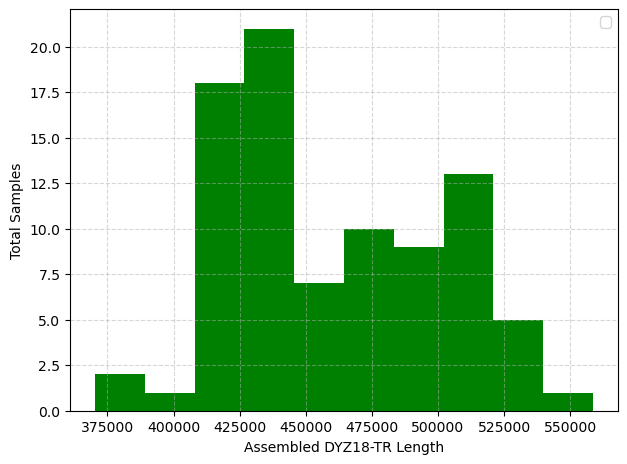

In [8]:
plt.xlabel('Assembled DYZ18-TR Length')
plt.ylabel('Total Samples')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.hist(hprc['NonDYZ1DYZ2Region'], log=False, color='green')

plt.legend()

#plt.savefig("/Users/loftum/Desktop/PersonalProjects/yq12Estimator/Figures/AllLengths.jpeg", format='jpeg', dpi=300, bbox_inches='tight')
#plt.savefig("/Users/loftum/Desktop/PersonalProjects/yq12Estimator/Figures/AllLengths.pdf", format='pdf', dpi=300, bbox_inches='tight')
plt.show()

In [9]:
import json

with open('/Users/loftum/Desktop/PersonalProjects/yq12Estimator/Yq12_Estimations/HGVSC_HPRC_LRKmer_Nov162025.json', 'r') as fp:
    FinalSampleDict= json.load(fp)

In [10]:
hgsvcDF = pd.DataFrame.from_dict(FinalSampleDict, orient='index', columns=['value'])
hgsvcDF.index.name = 'sample'
hgsvcDF.reset_index(inplace=True)

In [11]:
hgsvcDF[hgsvcDF['sample']=='HG01890']

,sample,value
7,HG01890,1.922620e+07


In [12]:
#hgsvcDF.to_csv("/Users/loftum/Desktop/LongReadKmer_Yq12Estimations.csv")

In [13]:
yhaploDF = pd.read_csv("/Users/loftum/Desktop/LeeLab/HPRC/chromosomeY/Information/old/1KGP_and_CEPH_only_annotations_1Ap2025.xlsx - Sheet1.tsv",sep='\t').set_index("Sample_ID")
yhaploDF['SmallHaplo']=[x[:3] for x in yhaploDF['yHaplo_hg_default']]

In [14]:
df = pd.read_csv('/Users/loftum/Desktop/LeeLab/YGrant/20130606_g1k_3202_samples_ped_population.txt',sep=' ')
males = df[(df['FatherID']!='0') & (df['Sex']!=2)].set_index("SampleID").copy()

In [15]:
Son2FatherPairs={}
Father2SonPairs={}
for sample in males.index:
    Son2FatherPairs[sample]=males.at[sample,'FatherID']

for sample in males.index:
    Father2SonPairs[males.at[sample,'FatherID']]=sample

In [16]:
Son2FatherPairs['200084']='200080'
Son2FatherPairs['NA12882']='NA12877'
Son2FatherPairs['NA12884']='NA12877'
Father2SonPairs['200080']='200084'
Father2SonPairs['NA12877']='NA12884'

In [17]:
hprcFatherSons = []
usedPairGroups=[]
for x in hprc.index:
    if x in Son2FatherPairs and Son2FatherPairs[x] in hprc.index:
        if '_'.join([Son2FatherPairs[x], x]) in usedPairGroups:
            continue
        else:
            hprcFatherSons.append([Son2FatherPairs[x], x, int(hprc.at[Son2FatherPairs[x],'TotalYq12Length'])-int(hprc.at[x,'TotalYq12Length'])])
            usedPairGroups.append('_'.join([Son2FatherPairs[x], x]))
    elif x in Father2SonPairs and Father2SonPairs[x] in hprc.index:
        if '_'.join([x, Father2SonPairs[x]]) in usedPairGroups:
            continue
        else:
            hprcFatherSons.append([x, Father2SonPairs[x], int(hprc.at[x,'TotalYq12Length'])-int(hprc.at[Father2SonPairs[x],'TotalYq12Length'])])
            usedPairGroups.append('_'.join([x, Father2SonPairs[x]]))
    else:
        continue

In [18]:
len(hprcFatherSons)

2

In [19]:
hprcFatherSons

[['200080', '200084', -29223], ['NA12877', 'NA12882', 30401]]

In [20]:
srkmerDF_mssing = pd.read_csv("/Users/loftum/Desktop/PersonalProjects/yq12Estimator/Yq12_Estimations/Assembled_Lengths_Estimated_extras.09232025.csv").set_index("Unnamed: 0")
goodRows=[]
count=1
for sample, polish, unpolish in zip(srkmerDF_mssing.index, srkmerDF_mssing['Polished'], srkmerDF_mssing['Unpolished']):
    if polish<unpolish:
        count+=1
        continue
    else:
        goodRows.append(sample)

srkmerDF_mssing2 = srkmerDF_mssing.loc[goodRows].copy()

In [21]:
srkmerDF_pre = pd.read_csv("/Users/loftum/Desktop/PersonalProjects/yq12Estimator/Yq12_Estimations/Assembled_Lengths_Estimated.09202025.csv").set_index("Unnamed: 0")
goodRows2=[]
for sample, polish, unpolish in zip(srkmerDF_pre.index, srkmerDF_pre['Polished'], srkmerDF_pre['Unpolished']):
    if polish<unpolish:
        print(sample)
        continue
    else:
        goodRows2.append(sample)

srkmerDF_pre2 = srkmerDF_pre.loc[goodRows2].copy()

In [22]:
srkmerDF_finalSamples = pd.read_csv("/Users/loftum/Desktop/PersonalProjects/yq12Estimator/Yq12_Estimations/Assembled_Lengths_Estimated_extras.12182025.csv").set_index("Unnamed: 0")
srkmerDF1 = pd.concat([srkmerDF_mssing2,srkmerDF_pre2,srkmerDF_finalSamples])
goodRows = [x for x,y,z in zip(srkmerDF1.index, srkmerDF1['Polished'], srkmerDF1['Unpolished']) if z<y]
weirdRows = [x for x,y,z in zip(srkmerDF1.index, srkmerDF1['Polished'], srkmerDF1['Unpolished']) if z>y]
srkmerDF = srkmerDF1.loc[goodRows].copy()
originalSamples=[x for x in srkmerDF.index]

In [23]:
for x in yhaploDF.index:
    if x in srkmerDF.index:
        continue
    else:
        print(x)

HG01392
NA12886
NA12882
NA12884
NA12883


In [24]:
#srkmerDF1.to_csv("/Users/loftum/Desktop/calculated.csv")

In [25]:
print("srkmerDF index unique:", srkmerDF.index.is_unique)
print("yhaploDF index unique:", yhaploDF.index.is_unique)
print("yhaploDF columns unique:", yhaploDF.columns.is_unique)

srkmerDF index unique: True
yhaploDF index unique: False
yhaploDF columns unique: True


In [26]:
hap = yhaploDF["yHaplo_hg_default"].groupby(level=0).first()

srkmerDF = srkmerDF.copy()
srkmerDF["YHaplo"] = srkmerDF.index.to_series().map(hap).fillna("NONE")
srkmerDF["YHaploBroad"] = srkmerDF["YHaplo"].where(
    srkmerDF["YHaplo"].eq("NONE"),
    srkmerDF["YHaplo"].astype(str).str.slice(0, 2)
)

missing = srkmerDF["YHaplo"].eq("NONE")
print("Missing:", int(missing.sum()))
print(srkmerDF.index[missing].tolist())

srkmerDF2 = srkmerDF.loc[~missing].copy()
srkmerDF2["Ratio"] = (
    srkmerDF2["DYZ1_Counts"].astype(float)
    .div(srkmerDF2["DYZ2_Counts"].astype(float))
    .replace([float("inf"), -float("inf")], float("nan"))
)


Missing: 3
['DPiPSC016.2J-bwa_GRCh38_FASpDecoyHLA.srt', 'HG02300', 'NA19226']


In [27]:
#srkmerDF2.to_csv("/Users/loftum/Desktop/PersonalProjects/yq12Estimator/FinalYq12_SRKmer_Estimations.csv")

In [28]:
np.mean(srkmerDF2['Unpolished'])

np.float64(26507962.73015539)

In [29]:
np.median(srkmerDF2['Unpolished'])

np.float64(25479106.795856517)

In [30]:
np.min(srkmerDF2['Unpolished'])

np.float64(931449.7886236968)

In [31]:
np.max(srkmerDF2['Unpolished'])

np.float64(52107355.789883)

In [32]:
longvsShortList=[]
for sample in originalSamples:
    if sample in FinalSampleDict:
        longvsShortList.append([sample,yhaploDF.at[sample,'yHaplo_hg_default'][:2], float(srkmerDF2.at[sample,'Polished']), float(srkmerDF2.at[sample,'Unpolished']),float(FinalSampleDict[sample])])
    else:
        continue
        #print(sample)
lvsDF = pd.DataFrame(data=longvsShortList, columns=['sample','YHaplogroup','SRKmer_polished','SRKmer_unpolished','LRKmer'])

In [33]:
shortListCompoarison=[]
for row in srkmerDF2.index:
    if row in set(hprc.index):
        shortListCompoarison.append([float(srkmerDF2.at[row,'Unpolished']), float(hprc.at[row, 'TotalYq12Length']),float(hprc.at[row, 'TotalYq12Length_onlyDYZ1DYZ2'])])
shortKmerOnlyCompDF = pd.DataFrame(data=shortListCompoarison, columns=['SRKmer_Estimation', 'Assembly_TotalYq12Length', 'Assembly_Yq12_OnlyDYZ1DYZ2'])

In [34]:
lvsDF['TotalYq12Length_Assembled'] = 'NONE'
lvsDF['TotalYq12Length_onlyDYZ1DYZ2_Assembled'] = 'NONE'
for row in lvsDF.index:
    if str(lvsDF.at[row,'sample']) in set(hprc.index):
        lvsDF.at[row,'TotalYq12Length_Assembled'] = float(hprc.at[str(lvsDF.at[row,'sample']), 'TotalYq12Length'])
        lvsDF.at[row,'TotalYq12Length_onlyDYZ1DYZ2_Assembled'] = float(hprc.at[str(lvsDF.at[row,'sample']), 'TotalYq12Length_onlyDYZ1DYZ2'])

In [35]:
knownVsEstimatedDF = lvsDF[lvsDF['TotalYq12Length_Assembled']!='NONE'].copy()

In [36]:
print(len(knownVsEstimatedDF))

74


In [37]:
knownVsEstimatedDF['SRKmer_polished']=knownVsEstimatedDF['SRKmer_polished'].astype(float)
knownVsEstimatedDF['SRKmer_unpolished']=knownVsEstimatedDF['SRKmer_unpolished'].astype(float)
knownVsEstimatedDF['LRKmer']=knownVsEstimatedDF['LRKmer'].astype(float)

n = 74
Pearson r = 0.986, p-value = 2.675e-57
R² = 0.971


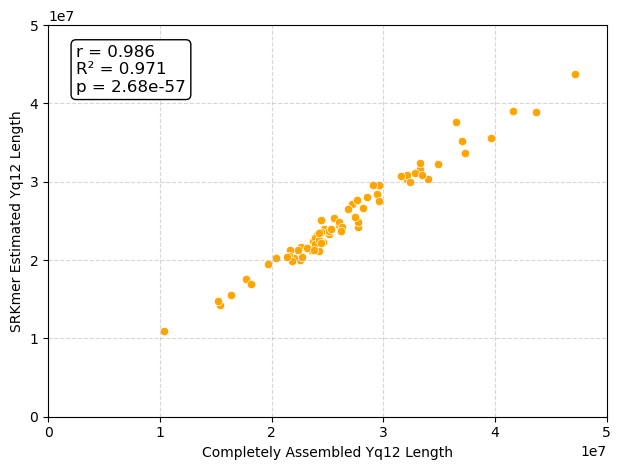

In [38]:
import numpy as np
import pandas as pd
from scipy.stats import pearsonr

xcol = 'SRKmer_unpolished'
ycol = 'TotalYq12Length_Assembled'

x_num = pd.to_numeric(knownVsEstimatedDF[xcol], errors='coerce')
y_num = pd.to_numeric(knownVsEstimatedDF[ycol], errors='coerce')

mask = x_num.replace([np.inf, -np.inf], np.nan).notna() & y_num.replace([np.inf, -np.inf], np.nan).notna()
x_clean = x_num[mask].to_numpy(dtype=float)
y_clean = y_num[mask].to_numpy(dtype=float)

if len(x_clean) == 0:
    raise ValueError("No valid numeric pairs after cleaning.")
if np.all(x_clean == x_clean[0]) or np.all(y_clean == y_clean[0]):
    raise ValueError("One of the inputs is constant; Pearson r is undefined.")

r, p_value = pearsonr(x_clean, y_clean)
print(f"n = {len(x_clean)}")
print(f"Pearson r = {r:.3f}, p-value = {p_value:.3e}")
print(f"R² = {r**2:.3f}")
r2 = r**2

import seaborn as sns
sns.scatterplot(knownVsEstimatedDF, x='TotalYq12Length_Assembled', y='SRKmer_unpolished', color='orange')
plt.xlabel('Completely Assembled Yq12 Length')
plt.ylabel('SRKmer Estimated Yq12 Length')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.xlim(left=0,right=50000000)
plt.ylim(bottom=0, top=50000000)


plt.plot(0, 50000000, 'r--', linewidth=1)  

plt.text(
    0.05, 0.95,
    f"r = {r:.3f}\nR² = {r2:.3f}\np = {p_value:.2e}",
    transform=plt.gca().transAxes,  # relative to axes (0–1 coords)
    verticalalignment="top",
    fontsize=12,
    bbox=dict(boxstyle="round,pad=0.3", edgecolor="black", facecolor="white")
)
#plt.savefig("/Users/loftum/Desktop/PersonalProjects/yq12Estimator/Figures/SRKmer_75assemblies.Jan92026.pdf", format='pdf', dpi=300, bbox_inches='tight')
#plt.savefig("/Users/loftum/Desktop/PersonalProjects/yq12Estimator/Figures/SRKmer_75assemblies.Jan92026.jpeg", format='jpeg', dpi=300, bbox_inches='tight')
plt.show()

In [135]:
knownVsEstimatedDF

,sample,YHaplogroup,SRKmer_polished,SRKmer_unpolished,LRKmer,TotalYq12Length_Assembled,TotalYq12Length_onlyDYZ1DYZ2_Assembled,rank_SRKmer_unpolished,rank_TotalYq12Length_Assembled,rank_difference,SRKmer_polished_rank,SRKmer_unpolished_rank,LRKmer_rank,TotalYq12Length_Assembled_rank,TotalYq12Length_onlyDYZ1DYZ2_Assembled_rank,Difference
1,HG00126,R1,2.625177e+07,2.236161e+07,1.917403e+07,24571708.0,24068185.0,49.0,40.0,9.0,48.0,49.0,63.0,40.0,40.0,-8.994481
3,HG00280,N1,3.313948e+07,2.840661e+07,2.768815e+07,29461652.0,28975988.0,21.0,21.0,0.0,21.0,21.0,20.0,21.0,21.0,-3.581061
4,HG00290,N1,3.514250e+07,3.035893e+07,2.033133e+07,32148720.0,31680858.0,15.0,16.0,-1.0,16.0,15.0,57.0,16.0,16.0,-5.567229
7,HG00358,N1,3.575068e+07,3.082411e+07,3.561944e+07,32152340.0,31681467.0,13.0,15.0,-2.0,15.0,13.0,7.0,15.0,15.0,-4.131046
8,HG00609,O2,4.544268e+07,3.896880e+07,3.721346e+07,43667553.0,43243238.0,3.0,2.0,1.0,2.0,3.0,4.0,2.0,2.0,-10.760287
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126,HG01505,R1,2.960427e+07,2.515647e+07,2.439646e+07,24443991.0,23943770.0,30.0,41.0,-11.0,29.0,30.0,32.0,41.0,43.0,2.914747
127,HG01596,O2,4.539839e+07,3.904737e+07,3.791576e+07,41643491.0,41232634.0,2.0,3.0,-1.0,3.0,2.0,3.0,3.0,3.0,-6.234151
128,HG02492,J2,2.460371e+07,2.128577e+07,2.401948e+07,23771651.0,23354663.0,57.0,53.0,4.0,60.0,57.0,35.0,53.0,53.0,-10.457353
129,HG03248,E1,3.460057e+07,2.992688e+07,2.825190e+07,32356425.0,31942904.0,17.0,14.0,3.0,18.0,17.0,17.0,14.0,14.0,-7.508704


In [139]:
import pandas as pd
from scipy.stats import spearmanr, kendalltau

rank1 = knownVsEstimatedDF["LRKmer_rank"]
rank2 = knownVsEstimatedDF["TotalYq12Length_Assembled_rank"]

from scipy.stats import pearsonr, kendalltau

tmp = knownVsEstimatedDF[
    ["LRKmer_rank", "TotalYq12Length_Assembled_rank"]
].dropna()

r_pearson, p_pearson = pearsonr(
    tmp["LRKmer_rank"],
    tmp["TotalYq12Length_Assembled_rank"]
)

tau, p_kendall = kendalltau(
    tmp["LRKmer_rank"],
    tmp["TotalYq12Length_Assembled_rank"]
)

print("Pearson r:", r_pearson)
print("Pearson p-value:", p_pearson)

print("Kendall tau:", tau)
print("Kendall p-value:", p_kendall)

Pearson r: 0.8173713439466864
Pearson p-value: 6.500255596920523e-19
Kendall tau: 0.6482784154017031
Kendall p-value: 3.0469216102183735e-16


In [39]:
import pandas as pd

col1 = "SRKmer_unpolished"
col2 = "TotalYq12Length_Assembled"

knownVsEstimatedDF["rank_" + col1] = knownVsEstimatedDF[col1].rank(ascending=False, method="min")
knownVsEstimatedDF["rank_" + col2] = knownVsEstimatedDF[col2].rank(ascending=False, method="min")

knownVsEstimatedDF["rank_difference"] = knownVsEstimatedDF["rank_" + col1] - knownVsEstimatedDF["rank_" + col2]

In [40]:
#just checking for ties
col1 = "SRKmer_unpolished"
col2 = "TotalYq12Length_Assembled"

print(knownVsEstimatedDF[col1].duplicated().sum())
print(knownVsEstimatedDF[col2].duplicated().sum())

0
0


In [41]:
rank_cols = [
    "SRKmer_polished",
    "SRKmer_unpolished",
    "LRKmer",
    "TotalYq12Length_Assembled",
    "TotalYq12Length_onlyDYZ1DYZ2_Assembled"
]

for col in rank_cols:
    knownVsEstimatedDF[f"{col}_rank"] = knownVsEstimatedDF[col].rank(ascending=False, method="min")

n = 74
Pearson r = 0.979, p-value = 7.926e-52
R² = 0.959


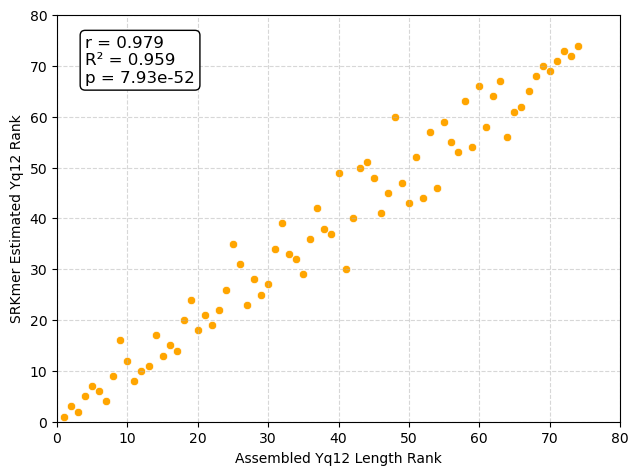

In [42]:
import numpy as np
import pandas as pd
from scipy.stats import pearsonr

xcol = 'rank_SRKmer_unpolished'
ycol = 'rank_TotalYq12Length_Assembled'

x_num = pd.to_numeric(knownVsEstimatedDF[xcol], errors='coerce')
y_num = pd.to_numeric(knownVsEstimatedDF[ycol], errors='coerce')

mask = x_num.replace([np.inf, -np.inf], np.nan).notna() & y_num.replace([np.inf, -np.inf], np.nan).notna()
x_clean = x_num[mask].to_numpy(dtype=float)
y_clean = y_num[mask].to_numpy(dtype=float)

if len(x_clean) == 0:
    raise ValueError("No valid numeric pairs after cleaning.")
if np.all(x_clean == x_clean[0]) or np.all(y_clean == y_clean[0]):
    raise ValueError("One of the inputs is constant; Pearson r is undefined.")

r, p_value = pearsonr(x_clean, y_clean)
print(f"n = {len(x_clean)}")
print(f"Pearson r = {r:.3f}, p-value = {p_value:.3e}")
print(f"R² = {r**2:.3f}")
r2 = r**2

import seaborn as sns
sns.scatterplot(knownVsEstimatedDF, x='rank_TotalYq12Length_Assembled', y='rank_SRKmer_unpolished', color='orange')
plt.xlabel('Assembled Yq12 Length Rank')
plt.ylabel('SRKmer Estimated Yq12 Rank')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.xlim(left=0,right=80)
plt.ylim(bottom=0, top=80)

plt.plot(0, 80, 'r--', linewidth=1)  


plt.text(
    0.05, 0.95,
    f"r = {r:.3f}\nR² = {r2:.3f}\np = {p_value:.2e}",
    transform=plt.gca().transAxes,  
    verticalalignment="top",
    fontsize=12,
    bbox=dict(boxstyle="round,pad=0.3", edgecolor="black", facecolor="white")
)
#plt.savefig("/Users/loftum/Desktop/PersonalProjects/yq12Estimator/Figures/SRKmer_75assemblies.Jan92026.pdf", format='pdf', dpi=300, bbox_inches='tight')
#plt.savefig("/Users/loftum/Desktop/PersonalProjects/yq12Estimator/Figures/SRKmer_75assemblies.Jan92026.jpeg", format='jpeg', dpi=300, bbox_inches='tight')
plt.show()

In [138]:
from scipy.stats import pearsonr, kendalltau

tmp = knownVsEstimatedDF[
    ["rank_SRKmer_unpolished", "TotalYq12Length_Assembled_rank"]
].dropna()

r_pearson, p_pearson = pearsonr(
    tmp["rank_SRKmer_unpolished"],
    tmp["TotalYq12Length_Assembled_rank"]
)

tau, p_kendall = kendalltau(
    tmp["rank_SRKmer_unpolished"],
    tmp["TotalYq12Length_Assembled_rank"]
)

print("Pearson r:", r_pearson)
print("Pearson p-value:", p_pearson)

print("Kendall tau:", tau)
print("Kendall p-value:", p_kendall)

Pearson r: 0.9794742687893373
Pearson p-value: 7.926301523762747e-52
Kendall tau: 0.8859681599407627
Kendall p-value: 5.881319780166614e-29


In [44]:
(0.886 + 1) / 2

0.9430000000000001

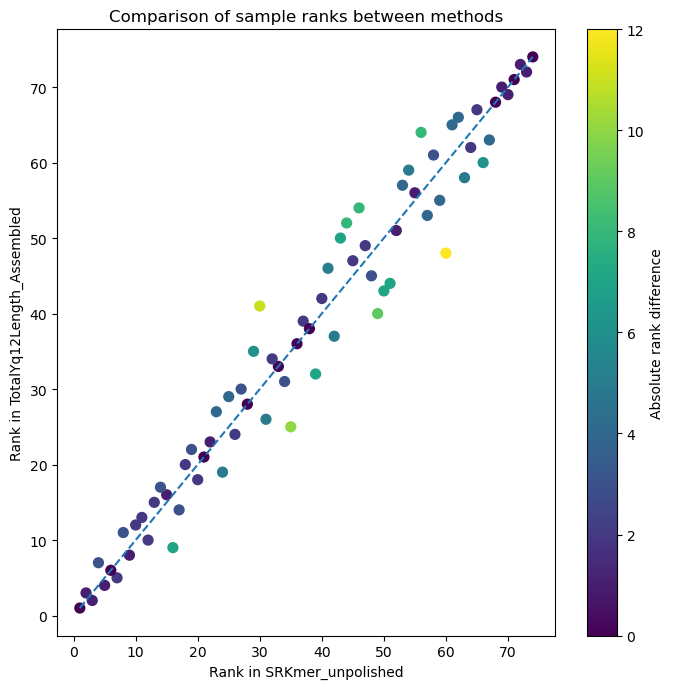

In [45]:
import pandas as pd
import matplotlib.pyplot as plt

col1 = "SRKmer_unpolished"
col2 = "TotalYq12Length_Assembled"

df = knownVsEstimatedDF.copy()

df["rank1"] = df[col1].rank(ascending=False, method="min")
df["rank2"] = df[col2].rank(ascending=False, method="min")
df["rank_diff"] = df["rank1"] - df["rank2"]
df["abs_rank_diff"] = df["rank_diff"].abs()

fig, ax = plt.subplots(figsize=(7, 7))

sc = ax.scatter(
    df["rank1"],
    df["rank2"],
    s=50,
    c=df["abs_rank_diff"]
)

min_rank = min(df["rank1"].min(), df["rank2"].min())
max_rank = max(df["rank1"].max(), df["rank2"].max())

ax.plot([min_rank, max_rank], [min_rank, max_rank], linestyle="--")

ax.set_xlabel(f"Rank in {col1}")
ax.set_ylabel(f"Rank in {col2}")
ax.set_title("Comparison of sample ranks between methods")

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Absolute rank difference")

plt.tight_layout()
plt.show()

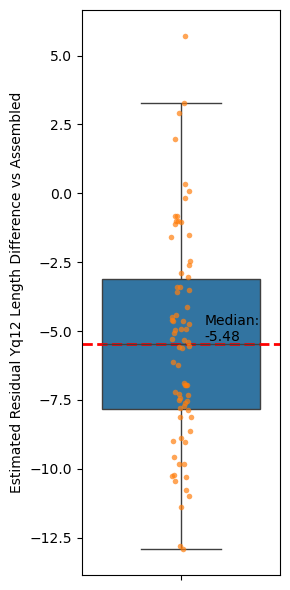

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

knownVsEstimatedDF["Difference"] = (
    100*((knownVsEstimatedDF["SRKmer_unpolished"] - knownVsEstimatedDF["TotalYq12Length_Assembled"])/knownVsEstimatedDF["TotalYq12Length_Assembled"])
)

median_val = knownVsEstimatedDF["Difference"].median()

plt.figure(figsize=(3, 6))
ax = sns.boxplot(data=knownVsEstimatedDF, y="Difference", showfliers=False)
sns.stripplot(data=knownVsEstimatedDF, y="Difference", ax=ax, jitter=0.05, size=4, alpha=0.7)

ax.axhline(median_val, linestyle="--", linewidth=2, color='red')

ax.text(
    0.62, median_val,
    f"Median:\n{median_val:.2f}",
    transform=ax.get_yaxis_transform(),   
    va="bottom", color='black'
)
plt.ylabel("Estimated Residual Yq12 Length Difference vs Assembled")
plt.tight_layout()
plt.show()


n = 74
Pearson r = 0.869, p-value = 1.005e-23
R² = 0.756


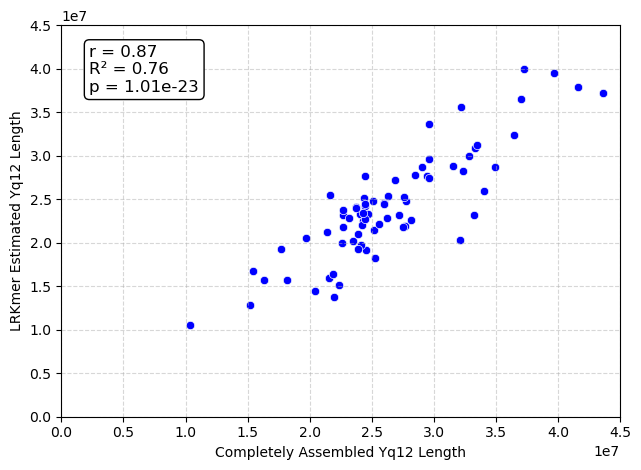

In [47]:
import numpy as np
import pandas as pd
from scipy.stats import pearsonr

xcol = 'LRKmer'
ycol = 'TotalYq12Length_Assembled'

x_num = pd.to_numeric(knownVsEstimatedDF[xcol], errors='coerce')
y_num = pd.to_numeric(knownVsEstimatedDF[ycol], errors='coerce')

mask = x_num.replace([np.inf, -np.inf], np.nan).notna() & y_num.replace([np.inf, -np.inf], np.nan).notna()
x_clean = x_num[mask].to_numpy(dtype=float)
y_clean = y_num[mask].to_numpy(dtype=float)

if len(x_clean) == 0:
    raise ValueError("No valid numeric pairs after cleaning.")
if np.all(x_clean == x_clean[0]) or np.all(y_clean == y_clean[0]):
    raise ValueError("One of the inputs is constant; Pearson r is undefined.")

r, p_value = pearsonr(x_clean, y_clean)
print(f"n = {len(x_clean)}")
print(f"Pearson r = {r:.3f}, p-value = {p_value:.3e}")
print(f"R² = {r**2:.3f}")
r2 = r**2

sns.scatterplot(knownVsEstimatedDF, x='TotalYq12Length_Assembled', y='LRKmer')
import seaborn as sns
sns.scatterplot(knownVsEstimatedDF, x='TotalYq12Length_Assembled', y='LRKmer', color='blue')
plt.xlabel('Completely Assembled Yq12 Length')
plt.ylabel('LRKmer Estimated Yq12 Length')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.xlim(left=0,right=45000000)
plt.ylim(bottom=0, top=45000000)


plt.text(
    0.05, 0.95,
    f"r = {r:.2f}\nR² = {r2:.2f}\np = {p_value:.2e}",
    transform=plt.gca().transAxes,  # relative to axes (0–1 coords)
    verticalalignment="top",
    fontsize=12,
    bbox=dict(boxstyle="round,pad=0.3", edgecolor="black", facecolor="white")
)
#plt.savefig("/Users/loftum/Desktop/PersonalProjects/yq12Estimator/Figures/LRKmer_vs70Samples.Jan92026.pdf", format='pdf', dpi=300, bbox_inches='tight')
#plt.savefig("/Users/loftum/Desktop/PersonalProjects/yq12Estimator/Figures/LRKmer_vs70Samples.Jan92026.jpeg", format='jpeg', dpi=300, bbox_inches='tight')
plt.show()

In [48]:
import numpy as np
from scipy.stats import pearsonr

x = np.array(knownVsEstimatedDF['SRKmer_unpolished'])
y = np.array(knownVsEstimatedDF['LRKmer'])
r, p_value = pearsonr(x, y)

print(f"Pearson r = {r:.3f}, p-value = {p_value:.3e}")
r2 = r**2

Pearson r = 0.874, p-value = 3.102e-24


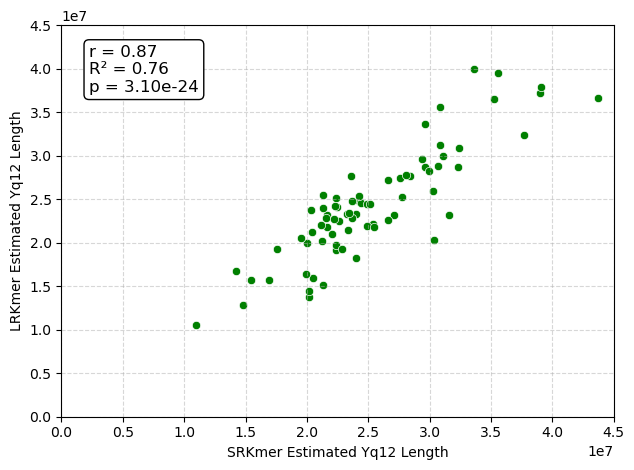

In [49]:
import seaborn as sns
sns.scatterplot(knownVsEstimatedDF, x='SRKmer_unpolished', y='LRKmer', color='green')
plt.xlabel('SRKmer Estimated Yq12 Length')
plt.ylabel('LRKmer Estimated Yq12 Length')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.xlim(left=0,right=45000000)
plt.ylim(bottom=0, top=45000000)


plt.text(
    0.05, 0.95,
    f"r = {r:.2f}\nR² = {r2:.2f}\np = {p_value:.2e}",
    transform=plt.gca().transAxes,  
    verticalalignment="top",
    fontsize=12,
    bbox=dict(boxstyle="round,pad=0.3", edgecolor="black", facecolor="white")
)
plt.plot(0, 45000000, 'r--', linewidth=1)
#plt.savefig("/Users/loftum/Desktop/PersonalProjects/yq12Estimator/Figures/LRKmer_vs_SRKmer_74Samples.Jan122026.pdf", format='pdf', bbox_inches='tight')
#plt.savefig("/Users/loftum/Desktop/PersonalProjects/yq12Estimator/Figures/LRKmer_vs_SRKmer_74Samples.Jan122026.jpeg", format='jpeg', dpi=300, bbox_inches='tight')
plt.show()

In [50]:
import pandas as pd

def rank_samples(df, sample_col, col1, col2, ascending=True):

    ranked = pd.DataFrame()
    ranked[sample_col] = df[sample_col]

    ranked[col1 + "_rank"] = df[col1].rank(method="min", ascending=ascending).astype(int)
    ranked[col2 + "_rank"] = df[col2].rank(method="min", ascending=ascending).astype(int)

    return ranked.sort_values(by=sample_col).reset_index(drop=True)


rankresult = rank_samples(knownVsEstimatedDF, "sample", "LRKmer", "SRKmer_unpolished", ascending=True)

In [51]:
rankresult['haplogroup']=[yhaploDF.at[x,'yHaplo_hg_default'][:2] for x in rankresult['sample']]

In [52]:
#srkmer31 = srkmerDF2[(srkmerDF2['DYZ1_Counts']!='NONE') & (srkmerDF2['DYZ2_Counts']!=79.718399)].copy()

In [53]:
srkmer3 = srkmerDF2.copy()

In [54]:
srkmer3['Ratio']=[float(x)/float(y)  for x,y in zip(srkmer3['DYZ1_Counts'], srkmer3['DYZ2_Counts'])]

In [55]:
np.median(srkmer3['Ratio'])

np.float64(0.9443857495792046)

In [56]:
import numpy as np
from scipy.stats import pearsonr

x = np.array([float(x) for x in srkmer3['DYZ1_Counts']])
y = np.array([float(x) for x in srkmer3['DYZ2_Counts']])
r, p_value = pearsonr(x, y)

print(f"Pearson r = {r:.3f}, p-value = {p_value:.3e}")
r2 = r**2

Pearson r = 0.864, p-value = 0.000e+00


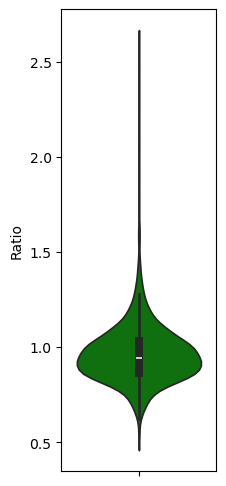

In [57]:
import seaborn as sns
plt.figure(figsize=(2,6))
sns.violinplot(data=srkmer3, y='Ratio',color='green')
#plt.savefig("/Users/loftum/Desktop/PersonalProjects/yq12Estimator/Figures/SRKmer_ratio_Violin.12192025.pdf", format='pdf', dpi=300, bbox_inches='tight')
plt.show()

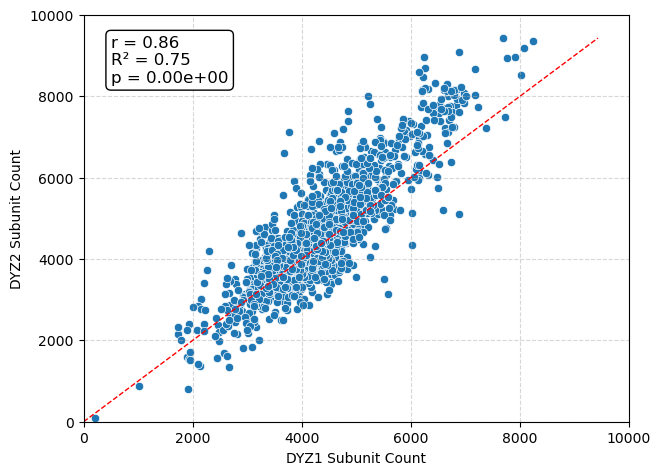

In [58]:
import seaborn as sns
sns.scatterplot(srkmer3, x='DYZ1_Counts', y='DYZ2_Counts')
plt.xlabel('DYZ1 Subunit Count')
plt.ylabel('DYZ2 Subunit Count')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.xlim(left=0, right=10000)
plt.ylim(bottom=0, top=10000)

lims = [0, max(x.max(), y.max())]  
plt.plot(lims, lims, 'r--', linewidth=1)  

plt.text(
    0.05, 0.95,
    f"r = {r:.2f}\nR² = {r2:.2f}\np = {p_value:.2e}",
    transform=plt.gca().transAxes,  
    verticalalignment="top",
    fontsize=12,
    bbox=dict(boxstyle="round,pad=0.3", edgecolor="black", facecolor="white")
)
#plt.savefig("/Users/loftum/Desktop/PersonalProjects/yq12Estimator/Figures/dyz1_vs_dyz2-ratio.12192025.pdf", format='pdf', dpi=300, bbox_inches='tight')
#plt.savefig("/Users/loftum/Desktop/PersonalProjects/yq12Estimator/Figures/dyz1_vs_dyz2-ratio.12192025.jpeg", format='jpeg', dpi=300, bbox_inches='tight')
plt.show()

In [59]:
maleCount=0
for sample in srkmerDF2.index:
    if sample in males.index and males.at[sample,'FatherID'] in srkmerDF2.index:
        maleCount+=1
print(maleCount)

309


In [60]:
#sampleList=[]
#directory='/Users/loftum/Desktop/PersonalProjects/yq12Estimator/Yq12_Estimations/FatherAndSons/'
#for file in os.listdir(directory):
#    sample = str(file.split(".")[0])
#    #print(sample)
#    tempDF = pd.read_csv(directory+file,sep='\t').T
#    sampleList.append([sample, float(tempDF.at['UnpolishedSize',0]), float(tempDF.at['DYZ1_Count',0]), float(tempDF.at['DYZ2_Count',0])])
#sampleDF = pd.DataFrame(data=sampleList, columns=['Sample','Yq12Length','DYZ1','DYZ2']).set_index("Sample")

In [61]:
comparisons=[]
pair=1
for sample in srkmerDF2.index:
    if sample in Son2FatherPairs.keys():
        if Son2FatherPairs[sample] in list(srkmerDF2.index):
            comparisons.append([sample,srkmerDF2.at[sample,'Unpolished'], srkmerDF2.at[sample,'Ratio'], 'Pair_'+str(pair),'Son', males.at[sample, 'Superpopulation'], srkmerDF2.at[sample,'YHaploBroad']])
            comparisons.append([Son2FatherPairs[sample], srkmerDF2.at[Son2FatherPairs[sample],'Unpolished'], srkmerDF2.at[Son2FatherPairs[sample],'Ratio'],'Pair_'+str(pair),'Father',males.at[sample, 'Superpopulation'],srkmerDF2.at[sample,'YHaploBroad']])
            pair+=1
        else:
            print('Son Sample: ',sample)
            continue

    else:
        print('Father Sample: ',sample)
        continue
comparisonDF = pd.DataFrame(data=comparisons, columns=['Sample','Length','Ratio','Pair','Type','Superpopulation','Haplogroup'])

Father Sample:  HG04191
Father Sample:  NA20512
Father Sample:  NA20532
Father Sample:  NA20901
Father Sample:  NA20903
Father Sample:  NA20904
Father Sample:  NA20911
Father Sample:  NA21087
Father Sample:  NA21090
Father Sample:  NA21091
Father Sample:  NA21092
Father Sample:  NA21094
Father Sample:  NA21095
Father Sample:  NA21098
Father Sample:  NA21099
Father Sample:  NA21100
Father Sample:  NA21104
Father Sample:  NA21105
Father Sample:  NA21109
Father Sample:  NA21111
Father Sample:  NA21112
Father Sample:  NA21113
Father Sample:  NA21114
Father Sample:  NA21115
Father Sample:  NA21116
Father Sample:  NA21117
Father Sample:  NA21118
Father Sample:  NA21119
Father Sample:  NA21123
Father Sample:  NA21124
Father Sample:  NA21126
Father Sample:  NA21127
Father Sample:  NA21128
Father Sample:  NA21129
Father Sample:  NA21130
Father Sample:  NA21133
Father Sample:  NA21135
Father Sample:  HG00096
Father Sample:  HG00101
Father Sample:  HG00103
Father Sample:  HG00105
Father Sample:  

In [62]:
colorDict={'AFR':'orange', 'AMR':'red', 'EAS':'pink', 'EUR':'blue', 'SAS':'lime'}

In [63]:
comparisonDF['color']= comparisonDF.Superpopulation.map(colorDict)
comparisonDF['pct_change'] = comparisonDF.groupby('Pair', sort=False)['Length'].apply(lambda x: x.pct_change()).to_numpy().round(3)*100
comparisonDF['pct_change']=comparisonDF['pct_change'].astype(float)

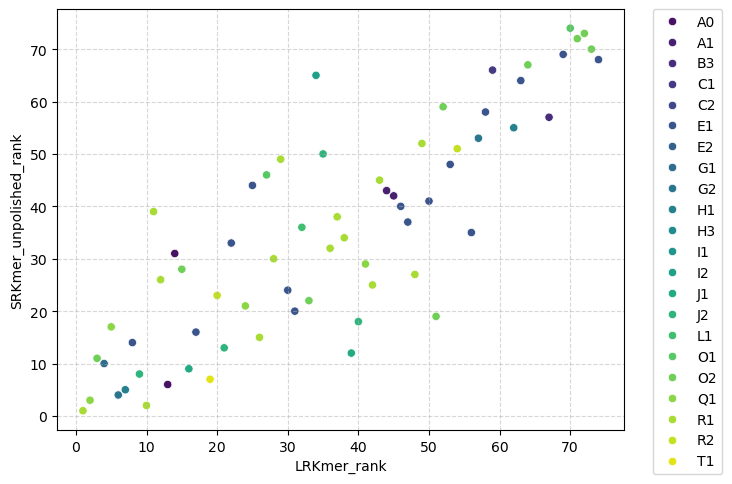

In [64]:
categories = sorted(comparisonDF['Haplogroup'].unique())

palette = dict(zip(
    categories,
    sns.color_palette("viridis", n_colors=len(categories))
))
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
sns.scatterplot(data=rankresult, x='LRKmer_rank',y='SRKmer_unpolished_rank', hue='haplogroup',    hue_order=categories,    # enforce category order
    palette=palette )
# Move legend outside the plot
plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1), borderaxespad=0.)

In [65]:
comparisonDF2 = comparisonDF.copy()

In [66]:
percent_changes = [float(x) for x in comparisonDF['pct_change'].dropna() if float(x) < 1000.0]

In [67]:
max(percent_changes)

112.1

In [68]:
#srkmerDF2.to_csv("/Users/loftum/Desktop/1597Samples_Yq12_information.csv")

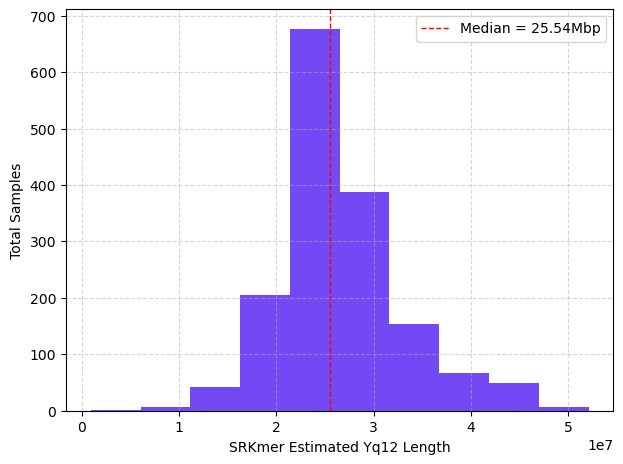

In [69]:
plt.xlabel('SRKmer Estimated Yq12 Length')
plt.ylabel('Total Samples')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.hist(srkmerDF2['Unpolished'], log=False, color='#7349F5')

median_val = np.median(srkmerDF2['Unpolished'])
plt.axvline(median_val, color="red", linestyle="--", linewidth=1, label=f"Median = 25.54Mbp")
plt.legend()

#plt.savefig("/Users/loftum/Desktop/PersonalProjects/yq12Estimator/Figures/AllLengths.12192025.jpeg", format='jpeg', dpi=300, bbox_inches='tight')
#plt.savefig("/Users/loftum/Desktop/PersonalProjects/yq12Estimator/Figures/AllLengths.12192025.pdf", format='pdf', dpi=300, bbox_inches='tight')
plt.show()

In [177]:
collections.Counter(comparisonDF2[comparisonDF2['Type']=='Father']['PairColor'])

Counter({'FatherLarger': 220, 'SonLarger': 89})

In [70]:
import numpy as np
import pandas as pd
from scipy.stats import wilcoxon, binomtest
fatherDF = comparisonDF2[comparisonDF2['Type']=='Father'].copy()
sonDF = comparisonDF2[comparisonDF2['Type']=='Son'].copy()
# Wilcoxon signed-rank test (two-sided by default)
stat, pval = wilcoxon([float(x) for x in fatherDF['pct_change']])
print(f"Wilcoxon signed-rank: stat={stat}, p={pval:.3g}")

# Optional: simple sign test
n_pos = (fatherDF["pct_change"] > 0).sum()
n_neg = (fatherDF["pct_change"] < 0).sum()
sign_test = binomtest(n_pos, n_pos+n_neg, p=0.5, alternative="two-sided")
print(f"Sign test: p={sign_test.pvalue:.3g}")

Wilcoxon signed-rank: stat=11195.5, p=1.3e-15
Sign test: p=1.2e-13


In [71]:
fatherDF["pct_change"].median(), fatherDF["pct_change"].mean()

(np.float64(2.7), np.float64(11.624919093851132))

In [72]:
d = np.asarray(sonDF['Length']) - np.asarray(fatherDF['Length'])   
direction = "increase" if np.median(d) > 0 else "decrease"

In [73]:
def hl_pseudomedian_ci(d, alpha=0.05, n_boot=10000, random_state=0):
    d = np.asarray(d, dtype=float)
    n = d.size
    walsh = (d[:, None] + d[None, :]) / 2
    walsh = walsh[np.triu_indices(n)]
    hl = np.median(walsh)

    rng = np.random.default_rng(random_state)
    boots = np.empty(n_boot)
    for b in range(n_boot):
        s = rng.choice(d, size=n, replace=True)
        w = (s[:, None] + s[None, :]) / 2
        boots[b] = np.median(w[np.triu_indices(n)])
    lo, hi = np.percentile(boots, [100*alpha/2, 100*(1-alpha/2)])
    return hl, lo, hi

hl, lo, hi = hl_pseudomedian_ci(d, alpha=0.05)
print(f"Hodges–Lehmann shift = {hl:.3g} ({direction}); 95% CI [{lo:.3g}, {hi:.3g}]")


Hodges–Lehmann shift = -6.77e+05 (decrease); 95% CI [-8.26e+05, -5.26e+05]


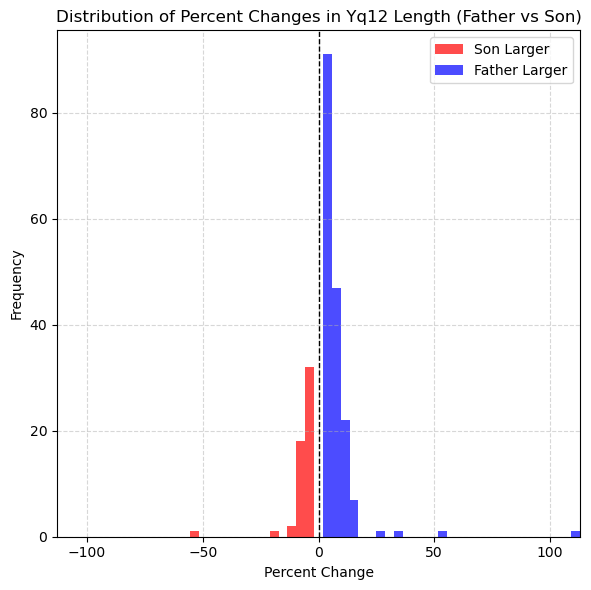

In [74]:
father_larger = [x for x in percent_changes if x > 0]
son_larger = [x for x in percent_changes if x < 0]

max_val = np.ceil(np.max(np.abs(percent_changes)))
bins = np.linspace(-max_val, max_val, 60)

son_counts, _ = np.histogram(son_larger, bins=bins)
father_counts, _ = np.histogram(father_larger, bins=bins)

bin_centers = (bins[:-1] + bins[1:]) / 2

plt.figure(figsize=(6, 6))

plt.bar(bin_centers[bin_centers < 0], son_counts[bin_centers < 0],
        width=np.diff(bins)[0], color='red', alpha=0.7, label='Son Larger')

plt.bar(bin_centers[bin_centers > 0], father_counts[bin_centers > 0],
        width=np.diff(bins)[0], color='blue', alpha=0.7, label='Father Larger')

plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.xlabel('Percent Change')
plt.ylabel('Frequency')
plt.title('Distribution of Percent Changes in Yq12 Length (Father vs Son)')
plt.xlim(-max_val, max_val)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

#plt.savefig("/Users/loftum/Desktop/PersonalProjects/yq12Estimator/Figures/FathervsSonPlot_Distribution.12192025.jpeg", format='jpeg', dpi=300, bbox_inches='tight')
#plt.savefig("/Users/loftum/Desktop/PersonalProjects/yq12Estimator/Figures/FathervsSonPlot_Distribution.12192025.pdf", format='pdf', dpi=300, bbox_inches='tight')
plt.show()

In [75]:
newList={x:{'son':0, 'father':0, 'Yhaplogroup':'None'} for x in set(comparisonDF2["Pair"])}
for row in comparisonDF2.index:
    newList[comparisonDF2.at[row,'Pair']][comparisonDF2.at[row,'Type'].lower()] = float(comparisonDF2.at[row,'Length'])
    newList[comparisonDF2.at[row,'Pair']]['Yhaplogroup']=comparisonDF2.at[row,'Haplogroup']

In [76]:
comparisonStatDF1 = pd.DataFrame(data=newList).T

In [77]:
import collections
goodGroups ={x for x,y in collections.Counter(comparisonStatDF1['Yhaplogroup']).items() if y>10}
comparisonStatDF = comparisonStatDF1[comparisonStatDF1['Yhaplogroup'].isin(goodGroups)].copy()

In [174]:
comparisonStatDF1

,son,father,Yhaplogroup
Pair_275,18937561.437645,19494587.611432,T1
Pair_268,18907480.482254,20767012.459667,Q1
Pair_236,18301371.611145,18207805.833723,E1
Pair_32,32421580.677304,30379693.055072,O2
Pair_64,22776990.801663,24060988.606778,E1
...,...,...,...
Pair_4,26776215.094466,27852600.845206,O1
Pair_75,28613306.607388,28523398.528312,J2
Pair_237,26452778.73671,25464304.403327,E1
Pair_208,12540533.312213,13251594.44942,G2


In [172]:
collections.Counter(comparisonStatDF['Yhaplogroup'])

Counter({'E1': 121, 'R1': 76, 'O2': 28, 'Q1': 15, 'O1': 13})

In [173]:
comparisonStatDF

,son,father,Yhaplogroup
Pair_268,18907480.482254,20767012.459667,Q1
Pair_236,18301371.611145,18207805.833723,E1
Pair_32,32421580.677304,30379693.055072,O2
Pair_64,22776990.801663,24060988.606778,E1
Pair_273,23584602.231379,24690566.655498,R1
...,...,...,...
Pair_246,23664750.687975,24719550.529468,E1
Pair_69,22897955.830195,25776024.032788,R1
Pair_305,25208962.601554,25710762.245897,E1
Pair_4,26776215.094466,27852600.845206,O1


In [78]:
import numpy as np, pandas as pd
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

df = comparisonStatDF.copy()
df['d'] = df['son'] - df['father']
df['sign_pos'] = (df['d'] > 0).astype(int)

groups = [g['d'].values for _, g in df.groupby('Yhaplogroup')]
H, p_kw = stats.kruskal(*groups)

X = pd.get_dummies(df['Yhaplogroup'], drop_first=True)
X = sm.add_constant(X)

df = df.copy()
df['d'] = pd.to_numeric(df['d'], errors='coerce')
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=['d', 'Yhaplogroup'])

ols = smf.ols('d ~ C(Yhaplogroup)', data=df).fit(cov_type='HC3')
print(ols.summary())

qr = smf.quantreg('d ~ C(Yhaplogroup)', df).fit(q=0.5)

print(f"Kruskal–Wallis: H={H:.2f}, p={p_kw:.3g}")
print(ols.summary())      
print(qr.summary())       


                            OLS Regression Results                            
Dep. Variable:                      d   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                 -0.007
Method:                 Least Squares   F-statistic:                     1.174
Date:                Mon, 06 Jul 2026   Prob (F-statistic):              0.323
Time:                        12:14:29   Log-Likelihood:                -4052.7
No. Observations:                 253   AIC:                             8115.
Df Residuals:                     248   BIC:                             8133.
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept            -8.724e+05 

/var/folders/xz/zh_wvx4s1xq705hg124_s53jqzy1bl/T/ipykernel_12905/2933946999.py:18: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=['d', 'Yhaplogroup'])
/Users/loftum/miniforge3/envs/myNewEnv/lib/python3.13/site-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +


## Plot

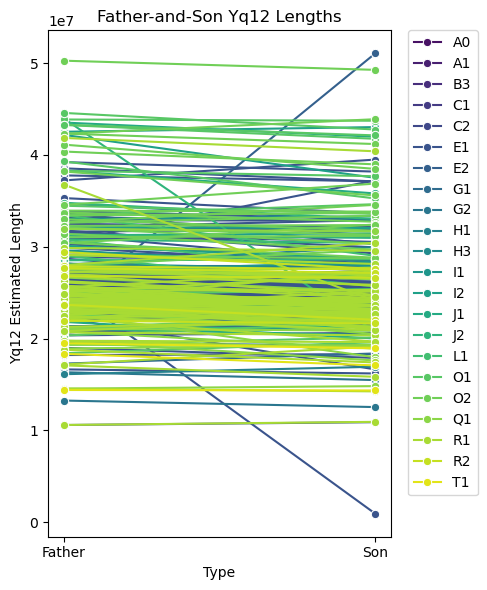

In [79]:
import seaborn as sns
import matplotlib.pyplot as plt

categories = sorted(comparisonDF2['Haplogroup'].unique())
palette = dict(zip(
    categories,
    sns.color_palette("viridis", n_colors=len(categories))
))

fig, ax = plt.subplots(figsize=(5,6), facecolor="#FFFFFF")

sns.lineplot(
    data=comparisonDF2.sort_values(by=['Type']),
    x='Type',
    y='Length',
    units='Pair',
    hue='Haplogroup',
    marker='o',
    legend=True,
    estimator=None,
    hue_order=categories,    
    palette=palette          
)

plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1), borderaxespad=0.)
plt.ylabel('Yq12 Estimated Length')
plt.title('Father-and-Son Yq12 Lengths')

plt.tight_layout()
#plt.savefig("/Users/loftum/Desktop/PersonalProjects/yq12Estimator/Figures/FathervsSonLinePlot.12192025.jpeg", format='jpeg', dpi=300, bbox_inches='tight')
#plt.savefig("/Users/loftum/Desktop/PersonalProjects/yq12Estimator/Figures/FathervsSonLinePlot.12192025.pdf", format='pdf', dpi=300, bbox_inches='tight')
plt.show()

In [80]:
PairColor = {x: ('SonLarger' if y < 0 else 'FatherLarger')
             for x, y in zip(comparisonDF2['Pair'], comparisonDF2['pct_change'])}

PercentChangeSize = {x:y for x, y in zip(comparisonDF2['Pair'], comparisonDF2['pct_change'])}

comparisonDF2['PairColor']=[PairColor[x] for x in comparisonDF2['Pair']]

In [81]:
smallPercentChangeGroup = [x for x,y in PercentChangeSize.items() if abs(float(y)) < 20.0]

In [82]:
print(len(smallPercentChangeGroup))
print(len(PercentChangeSize))

303
309


In [83]:
comparisonDF_Pair = comparisonDF2[comparisonDF2['Pair'].isin(smallPercentChangeGroup)].copy()

In [84]:
comparisonDF2.to_csv("/Users/loftum/Desktop/PersonalProjects/yq12Estimator/fatherSon_Yq12.csv")

In [85]:
len(set(comparisonDF_Pair['Pair']))

303

In [86]:
ratioList=[]
for pair in set(comparisonDF_Pair['Pair']):
    tempDF = comparisonDF_Pair[comparisonDF_Pair['Pair']==pair].reset_index().copy()
    ratioList.append([tempDF.at[0,'Ratio'], tempDF.at[1,'Ratio'],tempDF.at[1,'PairColor']])
ratioDF = pd.DataFrame(data=ratioList, columns=['Son','Father','Color'])

In [87]:
#ratioDF.to_csv("/Users/loftum/Desktop/PersonalProjects/yq12Estimator/fatherSon_RatioDF_Yq12.csv")

<Axes: xlabel='Son', ylabel='Father'>

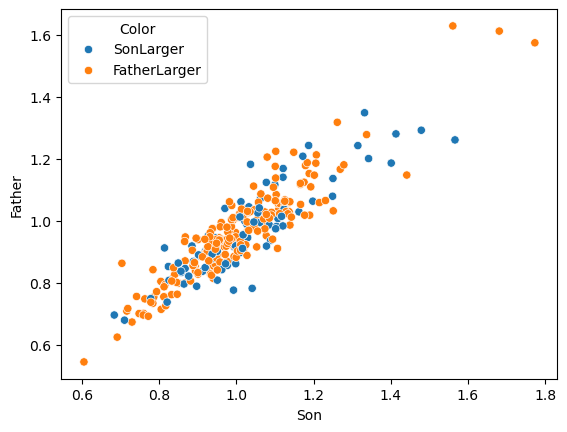

In [88]:
sns.scatterplot(data=ratioDF, x='Son',y='Father', hue='Color')

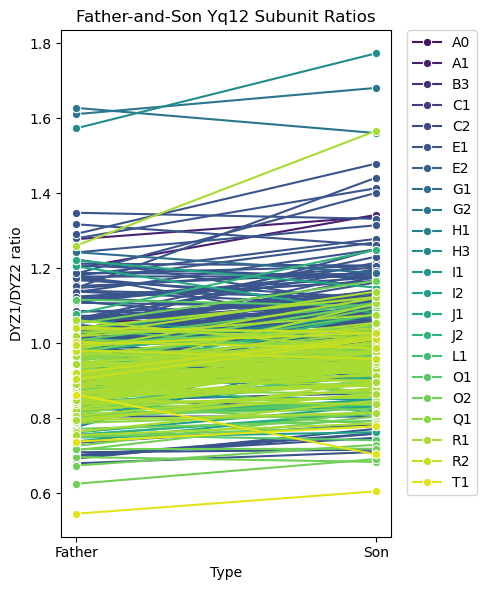

In [89]:
import seaborn as sns
import matplotlib.pyplot as plt

categories = sorted(comparisonDF2['Haplogroup'].unique())

palette = dict(zip(
    categories,
    sns.color_palette("viridis", n_colors=len(categories))
))

fig, ax = plt.subplots(figsize=(5,6), facecolor="#FFFFFF")

sns.lineplot(
    data=comparisonDF_Pair.sort_values(by=['Type']),
    x='Type',
    y='Ratio',
    units='Pair',
    hue='Haplogroup',
    marker='o',
    legend=True,
    estimator=None,
    hue_order=categories, 
    palette=palette         
)

plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1), borderaxespad=0.)
plt.ylabel('DYZ1/DYZ2 ratio')
plt.title('Father-and-Son Yq12 Subunit Ratios')

plt.tight_layout()
#plt.savefig("/Users/loftum/Desktop/PersonalProjects/yq12Estimator/Figures/FathervsSonLinePlot_Ratios.12192025.jpeg", format='jpeg', dpi=300, bbox_inches='tight')
#plt.savefig("/Users/loftum/Desktop/PersonalProjects/yq12Estimator/Figures/FathervsSonLinePlot_Ratios.12192025.pdf", format='pdf', dpi=300, bbox_inches='tight')
plt.show()

In [90]:
import seaborn as sns

In [91]:
srkmerDF2['Depth']=[sampleDepths[x] for x in srkmerDF2.index]

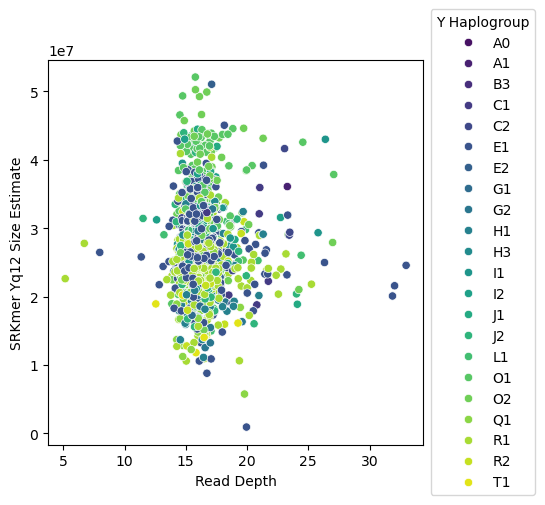

In [92]:
import matplotlib.pyplot as plt
import seaborn as sns

categories = sorted(comparisonDF2['Haplogroup'].unique())

palette = dict(zip(
    categories,
    sns.color_palette("viridis", n_colors=len(categories))
))

fig, ax = plt.subplots(figsize=(6, 5))

sns.scatterplot(
    data=srkmerDF2,
    x='Depth',
    y='Unpolished',
    hue='YHaploBroad',       
    palette=palette,          
    hue_order=categories,     
    ax=ax
)

ax.set_xlabel("Read Depth")
ax.set_ylabel("SRKmer Yq12 Size Estimate")

fig.subplots_adjust(right=0.75)   

ax.legend(
    title="Y Haplogroup",
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),   
    borderaxespad=0.
)
#plt.savefig("/Users/loftum/Desktop/PersonalProjects/yq12Estimator/Figures/SampleDepth_vs_Estimate.12192025.pdf", format='pdf', dpi=300, bbox_inches='tight')
plt.show()

/var/folders/xz/zh_wvx4s1xq705hg124_s53jqzy1bl/T/ipykernel_12905/2264887769.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(
/Users/loftum/miniforge3/envs/myNewEnv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 19.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/loftum/miniforge3/envs/myNewEnv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 21.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/loftum/miniforge3/envs/myNewEnv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 9.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  

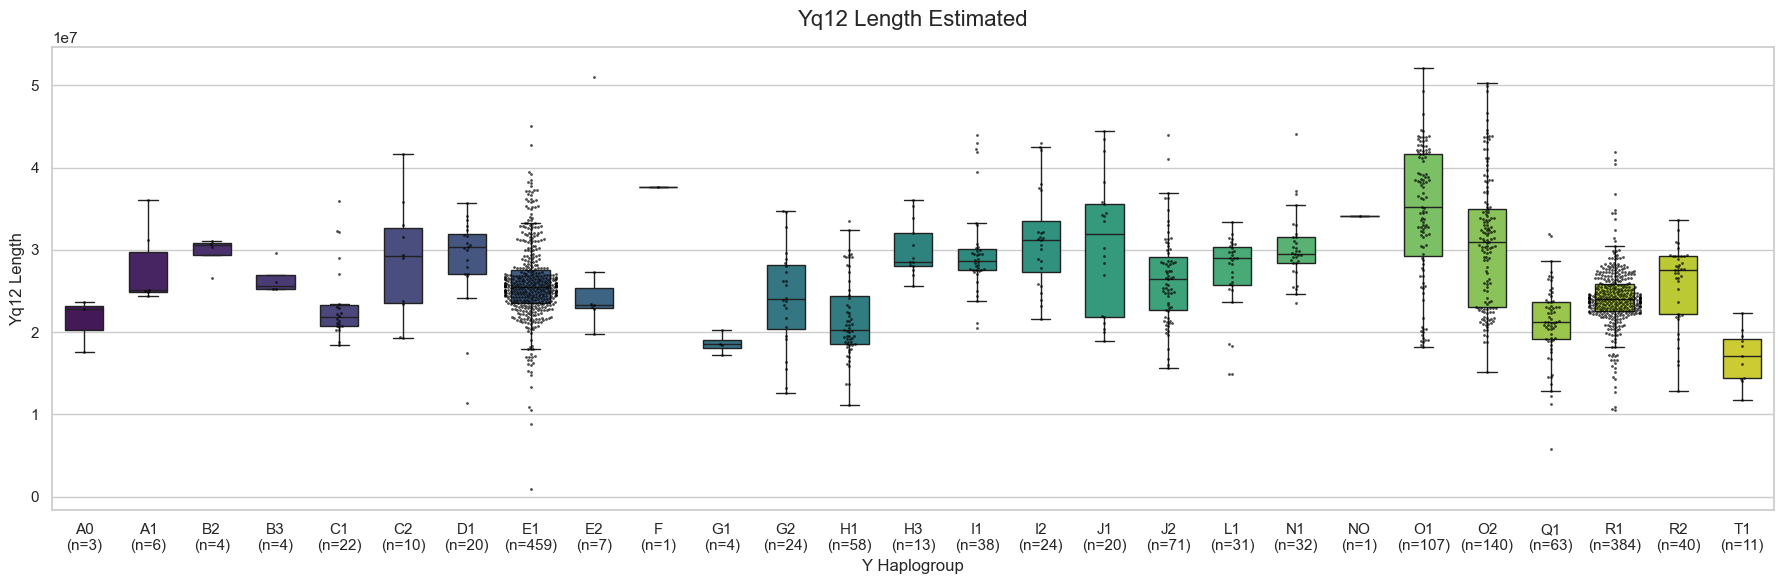

In [93]:
import seaborn as sns
import matplotlib.pyplot as plt

categories = sorted(srkmerDF2['YHaploBroad'].unique())
counts = srkmerDF2['YHaploBroad'].value_counts().reindex(categories)

sns.set_theme(style="whitegrid")

plt.figure(figsize=(18, 6))
ax = sns.boxplot(
    x="YHaploBroad",
    y="Unpolished",
    data=srkmerDF2,
    palette="viridis",
    order=categories,       
    showfliers=False,       
    width=0.6
)

sns.swarmplot(
    x="YHaploBroad",
    y="Unpolished",
    data=srkmerDF2,
    color="black",
    size=2,
    alpha=0.7,
    order=categories,
    ax=ax
)

new_labels = [f"{cat}\n(n={counts[cat]})" for cat in categories]
ax.set_xticks(range(len(categories)))
ax.set_xticklabels(new_labels, rotation=0, ha="center")

ax.set_title("Yq12 Length Estimated", fontsize=16, pad=15)
ax.set_xlabel("Y Haplogroup", fontsize=12)
ax.set_ylabel("Yq12 Length", fontsize=12)

plt.tight_layout()
#plt.savefig("/Users/loftum/Desktop/PersonalProjects/yq12Estimator/Figures/AllSamples_yHaplogroup.12192025.jpeg", format='jpeg', dpi=300, bbox_inches='tight')
#plt.savefig("/Users/loftum/Desktop/PersonalProjects/yq12Estimator/Figures/AllSamples_yHaplogroup.12192025.pdf", format='pdf', dpi=300, bbox_inches='tight')
plt.show()

In [132]:
srkmerDF2[(srkmerDF2['Unpolished']>=20_000_000)& (srkmerDF2['Unpolished']<=30_000_000)]

,Polished,Unpolished,DYZ1_Counts,DYZ2_Counts,YHaplo,YHaploBroad,Ratio,Depth,HaploMain
Unnamed: 0,,,,,,,,,
HG01178,2.817586e+07,2.419562e+07,3942.750928,4183.446512,R1b1a2a1a2a5,R1,0.942465,16.341132,R
HG02077,3.181865e+07,2.677622e+07,3917.941331,5286.397721,O1a1a1b2a,O1,0.741136,17.176419,O
HG03906,3.105220e+07,2.668961e+07,4512.555283,4373.677165,J2a1,J2,1.031753,16.731175,J
HG04191,2.511943e+07,2.132238e+07,3483.678482,3673.193323,H1a1d2,H1,0.948406,16.040100,H
NA12344,3.220682e+07,2.747455e+07,4503.711130,4711.075146,R1b1a2a1a2a,R1,0.955984,15.225298,R
...,...,...,...,...,...,...,...,...,...
NA19919,3.286034e+07,2.827034e+07,4752.523176,4672.967893,E1b1a1a1c1a1c,E1,1.017025,16.901615,E
NA20126,2.543945e+07,2.180395e+07,3528.168481,3806.576698,E1b1a1a1a,E1,0.926861,15.604605,E
NA20281,3.034093e+07,2.611408e+07,4344.991822,4382.978968,E1b1a1a1c1a1c,E1,0.991333,15.158107,E


In [133]:
1074/1597

0.6725109580463369

In [94]:
comparisonDF['Hap_Median'] = [np.median(srkmerDF2[srkmerDF2['YHaploBroad']==x]['Unpolished']) for x in comparisonDF['Haplogroup']]

In [95]:
comparisonDF['DifferenceFromMedian']=[int(x)-int(y) for x,y in zip(comparisonDF['Length'], comparisonDF['Hap_Median'])]

In [96]:
comparisonDF['DifferenceFromGlobalMedian']=[int(x)-int(np.median(srkmerDF2['Unpolished'])) for x in comparisonDF['Length']]

In [97]:
#comparisonDF.to_csv("/Users/loftum/Desktop/FatherSon_Yq12_information.csv")

In [98]:
FatherOnlyDFMed = comparisonDF[comparisonDF['Type']=='Father'].sort_values(by=['DifferenceFromMedian']).copy()

In [99]:
FatherOnlyDFMed2 = comparisonDF[comparisonDF['Type']=='Father'].sort_values(by=['DifferenceFromGlobalMedian']).copy()

In [100]:
FatherOnlyDFMed['F/S_Comparison']=['Son_Larger' if float(x)<0 else 'Father_Larger' for x in FatherOnlyDFMed['pct_change']]
FatherOnlyDFMed2['F/S_Comparison']=['Son_Larger' if float(x)<0 else 'Father_Larger' for x in FatherOnlyDFMed2['pct_change']]

In [101]:
fatherFiltered = FatherOnlyDFMed[(FatherOnlyDFMed['pct_change']>=-20.0) & (FatherOnlyDFMed['pct_change']<=20.0)].copy()

In [102]:
fatherFiltered2 = FatherOnlyDFMed2[(FatherOnlyDFMed2['pct_change']>=-20.0) & (FatherOnlyDFMed2['pct_change']<=20.0)].copy()

In [103]:
comparisonDFTemp = comparisonDF[comparisonDF['Pair'].isin(fatherFiltered['Pair'])].copy()

In [104]:
srkmerDF2['HaploMain']=[x[:1] for x in srkmerDF2['YHaploBroad']]

In [105]:
comparisonDFTemp['HaploMain']=[x[:1] for x in comparisonDFTemp['Haplogroup']]

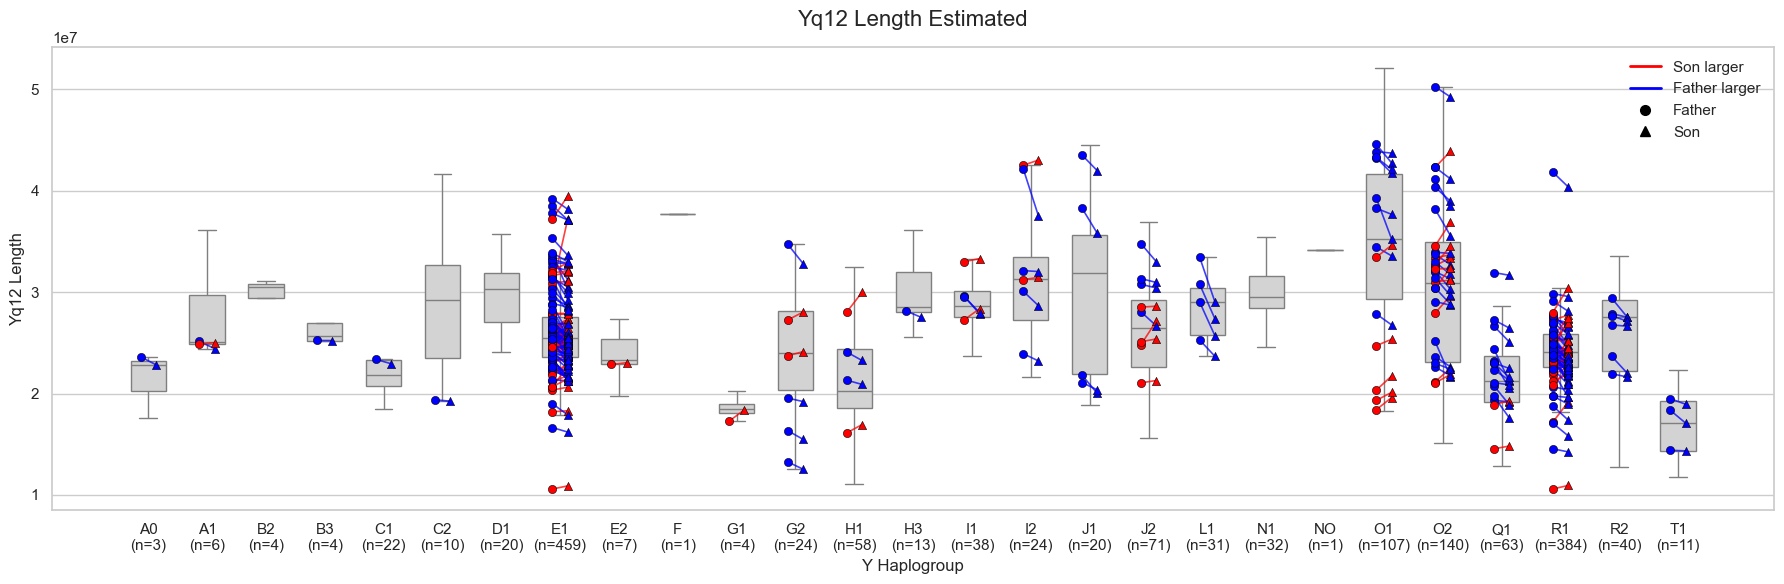

In [106]:
import re
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# -----------------------------
# 1. Boxplot data
# -----------------------------
categories = sorted(srkmerDF2['YHaploBroad'].dropna().unique())
counts = srkmerDF2['YHaploBroad'].value_counts().reindex(categories)

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(18, 6))

sns.boxplot(
    x="YHaploBroad",
    y="Unpolished",
    data=srkmerDF2,
    color="lightgrey",
    order=categories,
    showfliers=False,
    width=0.6,
    ax=ax
)

# -----------------------------
# 2. Prepare father/son data
# -----------------------------
pair_df = comparisonDFTemp.copy()

category_set = set(categories)

def map_to_plot_hap(hap):
    hap = str(hap)
    if hap in category_set:
        return hap
    
    broad = re.match(r"^[A-Z]+", hap)
    if broad and broad.group(0) in category_set:
        return broad.group(0)
    
    return None

pair_df["PlotHaplo"] = pair_df["Haplogroup"]#.apply(map_to_plot_hap)
pair_df = pair_df.dropna(subset=["PlotHaplo"])

cat_to_x = {cat: i for i, cat in enumerate(categories)}

# Small x-offsets so father and son are visible rather than directly overlapping
offsets = {
    "Father": -0.13,
    "Son": 0.13
}

# -----------------------------
# 3. Plot connected father/son pairs
# -----------------------------
for pair, sub in pair_df.groupby("Pair"):
    if not {"Father", "Son"}.issubset(set(sub["Type"])):
        continue

    father = sub[sub["Type"] == "Father"].iloc[0]
    son = sub[sub["Type"] == "Son"].iloc[0]

    # Usually father and son should have the same Y haplogroup.
    # Use the father's x-position for the pair.
    hap = father["PlotHaplo"]
    if hap not in cat_to_x:
        continue

    x_center = cat_to_x[hap]

    father_x = x_center + offsets["Father"]
    son_x = x_center + offsets["Son"]

    father_y = father["Length"]
    son_y = son["Length"]

    if son_y > father_y:
        line_color = "red"
    else:
        line_color = "blue"

    # Connecting line
    ax.plot(
        [father_x, son_x],
        [father_y, son_y],
        color=line_color,
        linewidth=1.2,
        alpha=0.75,
        zorder=3
    )

    # Father point
    ax.scatter(
        father_x,
        father_y,
        color=line_color,
        edgecolor="black",
        linewidth=0.4,
        s=35,
        marker="o",
        zorder=4
    )

    # Son point
    ax.scatter(
        son_x,
        son_y,
        color=line_color,
        edgecolor="black",
        linewidth=0.4,
        s=35,
        marker="^",
        zorder=4
    )

# -----------------------------
# 4. Labels and legend
# -----------------------------
new_labels = [f"{cat}\n(n={counts[cat]})" for cat in categories]
ax.set_xticks(range(len(categories)))
ax.set_xticklabels(new_labels, rotation=0, ha="center")

ax.set_title("Yq12 Length Estimated", fontsize=16, pad=15)
ax.set_xlabel("Y Haplogroup", fontsize=12)
ax.set_ylabel("Yq12 Length", fontsize=12)

legend_elements = [
    Line2D([0], [0], color="red", lw=2, label="Son larger"),
    Line2D([0], [0], color="blue", lw=2, label="Father larger"),
    Line2D([0], [0], marker="o", color="black", lw=0, label="Father", markersize=7),
    Line2D([0], [0], marker="^", color="black", lw=0, label="Son", markersize=7),
]

ax.legend(
    handles=legend_elements,
    frameon=False,
    loc="upper right"
)

plt.tight_layout()
plt.show()

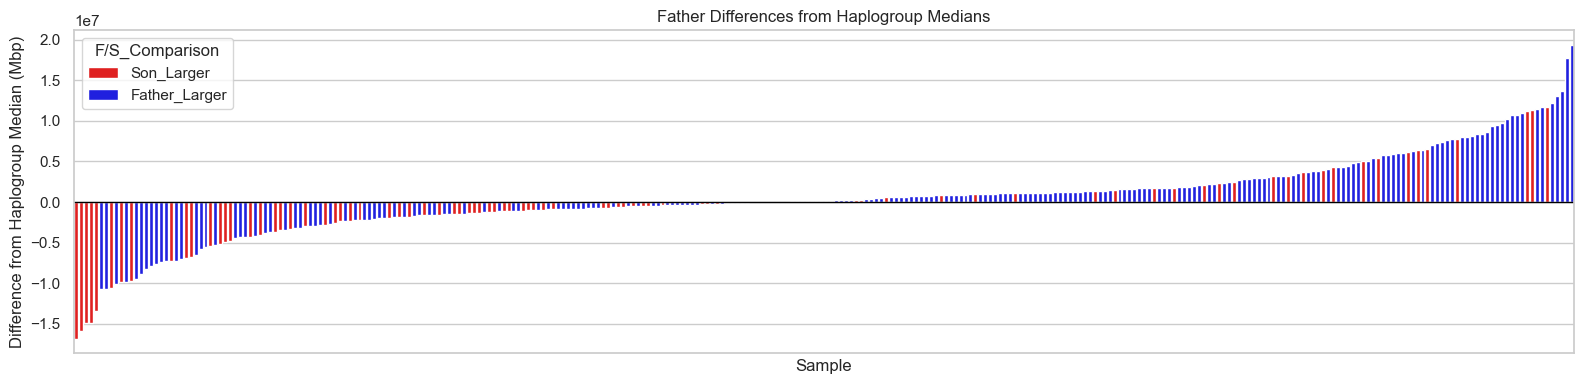

In [107]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
palette= {'Son_Larger':'red', 'Father_Larger':'blue'}
plt.figure(figsize=(16,4))
sns.barplot(data=fatherFiltered, x="Sample", y="DifferenceFromMedian", hue='F/S_Comparison',palette=palette)  # diverging palette

plt.axhline(0, color='black', linewidth=1)
plt.ylabel("Difference from Haplogroup Median (Mbp)")
plt.xticks([])
plt.xticks(rotation=90)
plt.title("Father Differences from Haplogroup Medians")
plt.tight_layout()
#plt.savefig("/Users/loftum/Desktop/PersonalProjects/yq12Estimator/Figures/FatherSonMedianDifferences.12192025.jpeg", format='jpeg', dpi=300, bbox_inches='tight')
#plt.savefig("/Users/loftum/Desktop/PersonalProjects/yq12Estimator/Figures/FatherSonMedianDifferences.12192025.pdf", format='pdf', dpi=300, bbox_inches='tight')

plt.show()


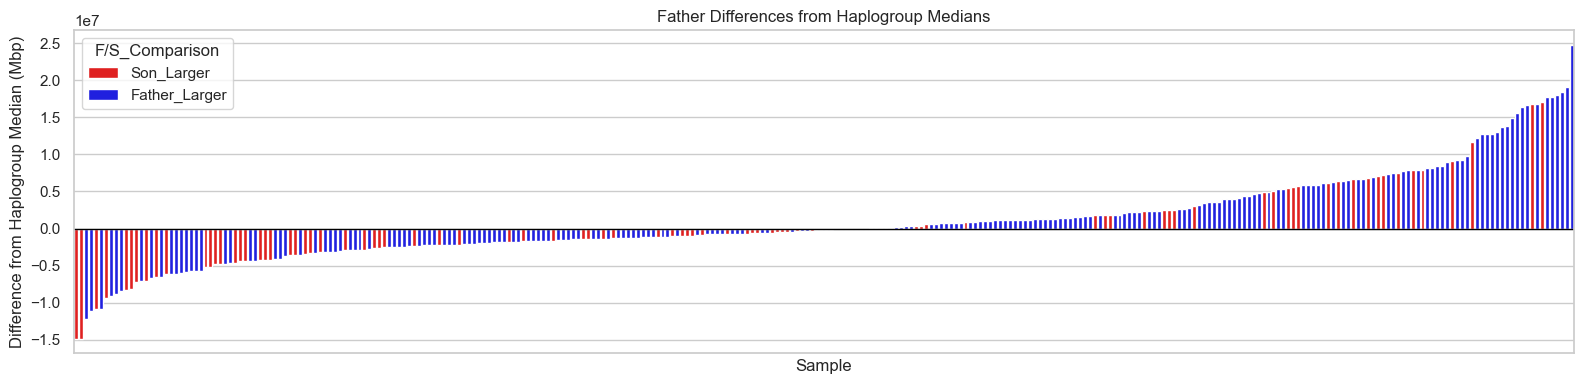

In [108]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
palette= {'Son_Larger':'red', 'Father_Larger':'blue'}
plt.figure(figsize=(16,4))
sns.barplot(data=fatherFiltered2, x="Sample", y="DifferenceFromGlobalMedian", hue='F/S_Comparison',palette=palette)  # diverging palette

plt.axhline(0, color='black', linewidth=1)
plt.ylabel("Difference from Haplogroup Median (Mbp)")
plt.xticks([])
plt.xticks(rotation=90)
plt.title("Father Differences from Haplogroup Medians")
plt.tight_layout()
#plt.savefig("/Users/loftum/Desktop/PersonalProjects/yq12Estimator/Figures/FatherSonMedianDifferences.12192025.jpeg", format='jpeg', dpi=300, bbox_inches='tight')
#plt.savefig("/Users/loftum/Desktop/PersonalProjects/yq12Estimator/Figures/FatherSonMedianDifferences.12192025.pdf", format='pdf', dpi=300, bbox_inches='tight')

plt.show()


In [109]:
# classify side of zero
fatherFiltered2["Side"] = np.where(fatherFiltered2["DifferenceFromGlobalMedian"] > 0, "Positive",
                      np.where(fatherFiltered2["DifferenceFromGlobalMedian"] < 0, "Negative", "Zero"))

#drop exact zeros for the sign test
df2 = fatherFiltered2[fatherFiltered2["Side"] != "Zero"].copy()

# 2×2 table
table2 = pd.crosstab(df2["F/S_Comparison"], df2["Side"])
print(table2)

Side            Negative  Positive
F/S_Comparison                    
Father_Larger        103       112
Son_Larger            57        31


In [110]:
from scipy.stats import chi2_contingency, fisher_exact
oddsratio, p_fisher = fisher_exact(table2)
print("Fisher p-value:", p_fisher)
print("odds ratio:", oddsratio)

Fisher p-value: 0.007986323772438474
odds ratio: 0.5001566416040101


In [111]:
# classify side of zero
fatherFiltered["Side"] = np.where(fatherFiltered["DifferenceFromMedian"] > 0, "Positive",
                      np.where(fatherFiltered["DifferenceFromMedian"] < 0, "Negative", "Zero"))

#drop exact zeros
df2 = fatherFiltered[fatherFiltered["Side"] != "Zero"].copy()

# 2×2 table
table = pd.crosstab(df2["F/S_Comparison"], df2["Side"])
print(table)

Side            Negative  Positive
F/S_Comparison                    
Father_Larger         80       135
Son_Larger            58        30


In [112]:
from scipy.stats import chi2_contingency, fisher_exact
oddsratio, p_fisher = fisher_exact(table)
print("Fisher p-value:", p_fisher)
print("odds ratio:", oddsratio)

Fisher p-value: 7.209688479247548e-06
odds ratio: 0.3065134099616858


/var/folders/xz/zh_wvx4s1xq705hg124_s53jqzy1bl/T/ipykernel_12905/914665022.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(
/Users/loftum/miniforge3/envs/myNewEnv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 39.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/loftum/miniforge3/envs/myNewEnv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 38.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/loftum/miniforge3/envs/myNewEnv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 6.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  w

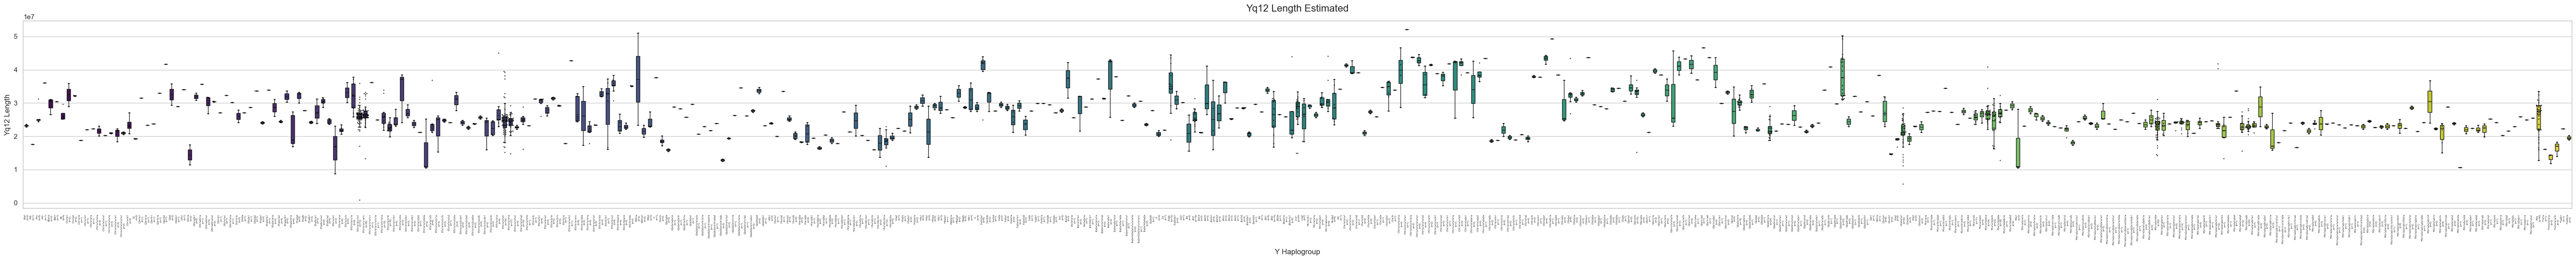

In [113]:
import seaborn as sns
import matplotlib.pyplot as plt

categories = sorted(srkmerDF2['YHaplo'].unique())
counts = srkmerDF2['YHaplo'].value_counts().reindex(categories)

sns.set_theme(style="whitegrid")

plt.figure(figsize=(58, 6))
ax = sns.boxplot(
    x="YHaplo",
    y="Unpolished",
    data=srkmerDF2,
    palette="viridis",
    order=categories,      
    showfliers=False,       
    width=0.6
)

sns.swarmplot(
    x="YHaplo",
    y="Unpolished",
    data=srkmerDF2,
    color="black",
    size=2,
    alpha=0.7,
    order=categories,
    ax=ax
)

new_labels = [f"{cat}\n(n={counts[cat]})" for cat in categories]
ax.set_xticks(range(len(categories)))
ax.set_xticklabels(new_labels, rotation=90, ha="center", fontsize=4)

ax.set_title("Yq12 Length Estimated", fontsize=16, pad=15)
ax.set_xlabel("Y Haplogroup", fontsize=12)
ax.set_ylabel("Yq12 Length", fontsize=12)

plt.tight_layout()
#plt.savefig("/Users/loftum/Desktop/PersonalProjects/yq12Estimator/Figures/AllSamples_yHaplogroup_nonBroad.12192025.jpeg", format='jpeg', dpi=300, bbox_inches='tight')
#plt.savefig("/Users/loftum/Desktop/PersonalProjects/yq12Estimator/Figures/AllSamples_yHaplogroup_nonBroad.12192025.pdf", format='pdf', dpi=300, bbox_inches='tight')
plt.show()

In [114]:
goodHaploGroups = [x for x,y in collections.Counter(srkmerDF2['YHaploBroad']).items() if y >10]

In [115]:
srkmerDFHaplos = srkmerDF2[srkmerDF2['YHaploBroad'].isin(goodHaploGroups)].copy()

In [116]:
srkmerDFHaplos

,Polished,Unpolished,DYZ1_Counts,DYZ2_Counts,YHaplo,YHaploBroad,Ratio,Depth,HaploMain
Unnamed: 0,,,,,,,,,
HG00477,3.913189e+07,3.367817e+07,5554.010268,5725.581489,O2a1a1b,O2,0.970034,16.585904,O
HG00526,5.727141e+07,4.925648e+07,8016.958933,8530.561094,O2a2b1a2a1,O2,0.939793,16.118842,O
HG01178,2.817586e+07,2.419562e+07,3942.750928,4183.446512,R1b1a2a1a2a5,R1,0.942465,16.341132,R
HG02077,3.181865e+07,2.677622e+07,3917.941331,5286.397721,O1a1a1b2a,O1,0.741136,17.176419,O
HG03906,3.105220e+07,2.668961e+07,4512.555283,4373.677165,J2a1,J2,1.031753,16.731175,J
...,...,...,...,...,...,...,...,...,...
NA19919,3.286034e+07,2.827034e+07,4752.523176,4672.967893,E1b1a1a1c1a1c,E1,1.017025,16.901615,E
NA20126,2.543945e+07,2.180395e+07,3528.168481,3806.576698,E1b1a1a1a,E1,0.926861,15.604605,E
NA20281,3.034093e+07,2.611408e+07,4344.991822,4382.978968,E1b1a1a1c1a1c,E1,0.991333,15.158107,E


In [117]:
import numpy as np, pandas as pd
from scipy import stats
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.multitest import multipletests
import itertools

df = srkmerDFHaplos.copy()
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=['Unpolished','YHaploBroad'])

summ = df.groupby('YHaploBroad')['Unpolished'].agg(['count','median','mean','std'])
print(summ.sort_values('count'))

groups = [g['Unpolished'].values for _, g in df.groupby('YHaploBroad')]
H, p_kw = stats.kruskal(*groups)
print(f"Kruskal–Wallis: H={H:.2f}, p={p_kw:.3g}")

N = len(df)
k = df['YHaploBroad'].nunique()
eps2 = (H - (k-1)) / (N - 1)
print(f"KW epsilon^2 ≈ {eps2:.3f}")

df['logL'] = np.log1p(df['Unpolished'])

import pingouin as pg  
welch = pg.welch_anova(dv='logL', between='YHaploBroad', data=df)
print(welch)

qr = smf.quantreg('Unpolished ~ C(YHaploBroad)', df).fit(q=0.5)
print(qr.summary())


             count        median          mean           std
YHaploBroad                                                 
T1              11  1.707538e+07  1.700775e+07  3.168170e+06
H3              13  2.853446e+07  3.002021e+07  3.327903e+06
J1              20  3.186721e+07  3.074255e+07  8.163598e+06
D1              20  3.030209e+07  2.874046e+07  5.722363e+06
C1              22  2.179759e+07  2.351882e+07  4.715499e+06
G2              24  2.400263e+07  2.413715e+07  6.109062e+06
I2              24  3.125843e+07  3.138992e+07  6.064762e+06
L1              31  2.901072e+07  2.726575e+07  4.739256e+06
N1              32  2.954699e+07  3.019539e+07  4.071294e+06
I1              38  2.866289e+07  2.986181e+07  5.498566e+06
R2              40  2.755171e+07  2.590365e+07  4.763628e+06
H1              58  2.021629e+07  2.163648e+07  4.920842e+06
Q1              63  2.127069e+07  2.112717e+07  4.624570e+06
J2              71  2.642689e+07  2.647042e+07  5.501940e+06
O1             107  3.52

/Users/loftum/miniforge3/envs/myNewEnv/lib/python3.13/site-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +


In [118]:
import numpy as np
from scipy import stats as st
import pingouin as pg

gh = pg.pairwise_gameshowell(dv='logL', between='YHaploBroad', data=df)

print("Columns:", gh.columns.tolist())

if 'CI95%' not in gh.columns:
    alpha = 0.05
    tcrit = st.t.ppf(1 - alpha/2, gh['df'])
    gh['CI_low']  = gh['diff'] - tcrit * gh['se']
    gh['CI_high'] = gh['diff'] + tcrit * gh['se']
    cols = ['A','B','mean(A)','mean(B)','diff','CI_low','CI_high','pval']
else:
    cols = ['A','B','mean(A)','mean(B)','diff','CI95%','pval']

print(gh[cols].sort_values('pval'))


Columns: ['A', 'B', 'mean(A)', 'mean(B)', 'diff', 'se', 'T', 'df', 'pval', 'hedges']
      A   B    mean(A)    mean(B)      diff    CI_low   CI_high          pval
42   E1  O1  17.049667  17.324218 -0.274551 -0.329597 -0.219505  0.000000e+00
69   H1  O1  16.864913  17.324218 -0.459305 -0.536620 -0.381991  0.000000e+00
144  O2  R1  17.210661  16.988816  0.221845  0.176408  0.267281  6.550316e-15
139  O1  Q1  17.324218  16.836405  0.487814  0.404614  0.571013  1.709743e-14
140  O1  R1  17.324218  16.988816  0.335402  0.282434  0.388370  3.441691e-14
..   ..  ..        ...        ...       ...       ...       ...           ...
46   E1  R2  17.049667  17.050188 -0.000522 -0.071309  0.070266  1.000000e+00
2    C1  G2  16.956577  16.964992 -0.008415 -0.146612  0.129782  1.000000e+00
82   H3  O2  17.211917  17.210661  0.001256 -0.074341  0.076852  1.000000e+00
88   I1  J1  17.197109  17.205806 -0.008697 -0.148077  0.130684  1.000000e+00
110  J1  N1  17.205806  17.215051 -0.009245 -0.145247  0.

In [119]:
def cliffs_delta(x, y):
    x = np.asarray(x); y = np.asarray(y)
    # count pairwise comparisons
    diffs = (x[:,None] > y).sum() - (x[:,None] < y).sum()
    return diffs / (x.size * y.size)

pairs = []
for a, b in itertools.combinations(df['YHaploBroad'].unique(), 2):
    xa = df.loc[df.YHaploBroad==a, 'Unpolished'].values
    xb = df.loc[df.YHaploBroad==b, 'Unpolished'].values
    pairs.append((a, b, cliffs_delta(xa, xb)))
pd.DataFrame(pairs, columns=['A','B','CliffsDelta']).sort_values('CliffsDelta')


,A,B,CliffsDelta
150,T1,H3,-1.000000
96,Q1,H3,-0.924298
93,Q1,N1,-0.900794
91,Q1,I2,-0.862434
151,T1,D1,-0.854545
...,...,...,...
45,O1,T1,0.940527
14,O2,T1,0.951948
129,I1,T1,0.990431
135,I2,T1,0.992424


In [120]:
def hl_two_sample(x, y):
    X, Y = np.asarray(x), np.asarray(y)
    return np.median(X[:,None] - Y[None,:])

def hl_ci_two_sample(x, y, B=3000, alpha=0.05, rng=0):
    rng = np.random.default_rng(rng)
    x = np.asarray(x); y = np.asarray(y)
    est = hl_two_sample(x, y)
    boots = []
    for _ in range(B):
        xb = rng.choice(x, size=len(x), replace=True)
        yb = rng.choice(y, size=len(y), replace=True)
        boots.append(hl_two_sample(xb, yb))
    lo, hi = np.percentile(boots, [100*alpha/2, 100*(1-alpha/2)])
    return est, lo, hi

rows = []
for a, b in itertools.combinations(df['YHaploBroad'].unique(), 2):
    xa = df.loc[df.YHaploBroad==a, 'Unpolished']
    xb = df.loc[df.YHaploBroad==b, 'Unpolished']
    est, lo, hi = hl_ci_two_sample(xa, xb)
    rows.append({'A':a,'B':b,'HL_diff(A-B)':est,'CI_lo':lo,'CI_hi':hi,
                 'nA':len(xa),'nB':len(xb)})
pd.DataFrame(rows).sort_values(['A','B'])


,A,B,HL_diff(A-B),CI_lo,CI_hi,nA,nB
116,C1,D1,-7.168450e+06,-9.442910e+06,-3.832172e+06,22,20
113,C1,G2,-1.547778e+06,-4.608506e+06,2.461754e+06,22,24
115,C1,H3,-6.996235e+06,-9.162916e+06,-5.298875e+06,22,13
109,C1,I1,-6.699042e+06,-7.944354e+06,-5.032080e+06,22,38
110,C1,I2,-8.345531e+06,-1.041369e+07,-4.841772e+06,22,24
...,...,...,...,...,...,...,...
99,R2,L1,-1.436508e+06,-2.998754e+06,3.596516e+05,40,31
103,R2,N1,-2.914168e+06,-5.408108e+06,-1.483459e+06,40,32
105,R2,T1,9.510509e+06,7.313962e+06,1.222519e+07,40,11
151,T1,D1,-1.272498e+07,-1.555350e+07,-1.007707e+07,11,20


In [121]:
import numpy as np, pandas as pd
import scikit_posthocs as sp  

summ = df.groupby('YHaploBroad')['Unpolished'].agg(n='count',
                                               median='median',
                                               IQR=lambda s: s.quantile(0.75)-s.quantile(0.25))
print(summ.sort_values('median'))

dunn = sp.posthoc_dunn(df, val_col='Unpolished', group_col='YHaploBroad', p_adjust='fdr_bh')
sig = (dunn.stack()
           .rename('p_adj')
           .reset_index()
           .rename(columns={'level_0':'A','level_1':'B'})
           .query('A < B and p_adj < 0.05')
           .sort_values('p_adj'))
print(sig.head(20))

def hl_two_sample(x, y):
    X, Y = np.asarray(x), np.asarray(y)
    return np.median(X[:,None] - Y[None,:])

def hl_ci_two_sample(x, y, B=3000, alpha=0.05, rng=0):
    rng = np.random.default_rng(rng)
    est = hl_two_sample(x, y)
    boots = []
    for _ in range(B):
        xb = rng.choice(x, size=len(x), replace=True)
        yb = rng.choice(y, size=len(y), replace=True)
        boots.append(hl_two_sample(xb, yb))
    lo, hi = np.percentile(boots, [100*alpha/2, 100*(1-alpha/2)])
    return est, lo, hi

pairs = []
groups = {g: df.loc[df.YHaploBroad==g, 'Unpolished'].values for g in df['YHaploBroad'].unique()}
for i, A in enumerate(groups):
    for B in list(groups)[i+1:]:
        est, lo, hi = hl_ci_two_sample(groups[A], groups[B])
        pairs.append({'A':A,'B':B,'HL_diff(A-B)':est,'CI_lo':lo,'CI_hi':hi})
hl_tbl = pd.DataFrame(pairs).sort_values('HL_diff(A-B)')
print(hl_tbl.head(10))


               n        median           IQR
YHaploBroad                                 
T1            11  1.707538e+07  4.842002e+06
H1            58  2.021629e+07  5.879359e+06
Q1            63  2.127069e+07  4.531629e+06
C1            22  2.179759e+07  2.524604e+06
G2            24  2.400263e+07  7.739331e+06
R1           384  2.408389e+07  3.252415e+06
E1           459  2.552074e+07  3.981562e+06
J2            71  2.642689e+07  6.547132e+06
R2            40  2.755171e+07  7.040793e+06
H3            13  2.853446e+07  3.967040e+06
I1            38  2.866289e+07  2.635969e+06
L1            31  2.901072e+07  4.593557e+06
N1            32  2.954699e+07  3.109204e+06
D1            20  3.030209e+07  4.823848e+06
O2           140  3.091104e+07  1.191880e+07
I2            24  3.125843e+07  6.183470e+06
J1            20  3.186721e+07  1.373405e+07
O1           107  3.525789e+07  1.236190e+07
      A   B         p_adj
231  O1  R1  3.990064e-32
230  O1  Q1  2.029037e-30
84   H1  O1  1.851334e

In [122]:
group_col = 'YHaploBroad' 
val_col   = 'Unpolished'

summ = (df
        .dropna(subset=[group_col, val_col])
        .groupby(group_col)[val_col]
        .agg(n='count',
             median='median',
             IQR=lambda s: s.quantile(0.75) - s.quantile(0.25))
        .sort_values('median'))

smallest_grp, smallest_med = summ.iloc[0].name, summ.iloc[0].median
largest_grp,  largest_med  = summ.iloc[-1].name, summ.iloc[-1].median

In [123]:
smallest_grp

'T1'

In [124]:
largest_grp

'O1'

In [125]:
np.median(df[df['YHaploBroad']=='T1']['Unpolished'])

np.float64(17075382.795659956)

In [126]:
np.mean(df[df['YHaploBroad']=='T1']['Unpolished'])

np.float64(17007753.89059439)

In [127]:
np.median(df[df['YHaploBroad']=='O1']['Unpolished'])

np.float64(35257888.68340731)

In [128]:
np.mean(df[df['YHaploBroad']=='O1']['Unpolished'])

np.float64(34483852.46254645)

In [129]:
smallest_med

<bound method Series.median of n         1.100000e+01
median    1.707538e+07
IQR       4.842002e+06
Name: T1, dtype: float64>

In [130]:
largest_med

<bound method Series.median of n         1.070000e+02
median    3.525789e+07
IQR       1.236190e+07
Name: O1, dtype: float64>